In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from pybedtools import BedTool

In [3]:
PROJECT_ROOT = Path("/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg")
notebook_dir = PROJECT_ROOT / "analysis" / "04_lad_analysis"
segmentation_results_path = PROJECT_ROOT / "results" / "01_region_calling_analysis"
REFERENCE_DATA_DIR = PROJECT_ROOT / "data" / "reference_data"
CHROMATIN_DATA_DIR = PROJECT_ROOT / "data" / "chromatin_data"

In [4]:
DEFAULT_SELECTED_SAMPLES = [
    "ESO26.wgbs",
    # "SRR26107673",
    "TE5.wgbs",
    "WGBS_colon-primary-tumor_1_meth",
    # "WGBS_colon-primary-tumor_2_meth",
    # "WGBS_colon-primary-tumor_3_meth",
]

In [ ]:
import yaml
from pathlib import Path


def resolve_sample_genome(sample, base_dir):
    candidate_tools = [
        "methylseg",
        "methylseekr",
        "dnmtools",
        "mmseekr",
        "methyl_lasso",
    ]

    for tool in candidate_tools:
        config_path = Path(base_dir) / tool / sample / "prep" / "config.yaml"
        if config_path.exists():
            with open(config_path) as f:
                genome = yaml.safe_load(f).get("genome", "").strip()
                if genome in {"hg19", "hg38"}:
                    return genome
                raise ValueError(f"Unsupported genome {genome} for {sample}")

    if sample.startswith("WGBS_colon") or sample.endswith(".wgbs"):
        return "hg38"
    return "hg19"

In [6]:
resolved_sample_genomes = {
    sample: resolve_sample_genome(sample, segmentation_results_path) for sample in DEFAULT_SELECTED_SAMPLES 
}

In [7]:
import subprocess


def run_liftover(input_bed, output_bed, chain_file, script_path):
    if Path(output_bed).exists():
        return output_bed

    cmd = [
        "Rscript",
        str(script_path),
        "--input-bed",
        str(input_bed),
        "--output-bed",
        str(output_bed),
        "--chain-file",
        str(chain_file),
    ]
    subprocess.run(cmd, check=True)
    return output_bed

def prepare_lads_for_lad_overlap(lad_df): 
    lads = lad_df.copy().reset_index(drop=True) 
    lads["lad_id"] = np.arange(len(lads)) 
    if "lad_length" not in lads.columns: 
        if "length" in lads.columns: 
            lads["lad_length"] = lads["length"] 
        else: 
            lads["lad_length"] = lads["end"] - lads["start"] 
        
    return lads

def load_lad_for_genome(
    genome,
    hg19_lad_path,
    cache_dir,
    liftover_script,
    chain_file,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    if genome == "hg19":
        path = Path(hg19_lad_path)

    elif genome == "hg38":
        lifted_path = cache_dir / "laminB1Lads.hg38.bed"

        if not lifted_path.exists():
            run_liftover(
                input_bed=hg19_lad_path,
                output_bed=lifted_path,
                chain_file=chain_file,
                script_path=liftover_script,
            )

        path = lifted_path

    else:
        raise ValueError(f"Unsupported genome: {genome}")

    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "name", "score", "strand"],
        dtype={"chrom": "string", "start": "int64", "end": "int64"},
    )
    return prepare_lads_for_lad_overlap(df)

def build_lad_lookup(samples, base_dir, hg19_lad_path, cache_dir, liftover_script, chain_file):
    sample_genomes = {
        sample: resolve_sample_genome(sample, base_dir)
        for sample in samples
    }

    unique_genomes = set(sample_genomes.values())

    lad_lookup = {
        genome: load_lad_for_genome(
            genome,
            hg19_lad_path,
            cache_dir,
            liftover_script,
            chain_file,
        )
        for genome in unique_genomes
    }

    return sample_genomes, lad_lookup

In [8]:
lad_interval_track_path = REFERENCE_DATA_DIR / "LAD_intervals.bed"

In [9]:
def get_sample_chromatin_broadpeaks(sample_id):
    sample_id = sample_id.replace(".wgbs", "")
    return CHROMATIN_DATA_DIR / f"{sample_id}.h3k36me2.broadPeak.gz"

In [10]:
sample_genomes, lad_lookup = build_lad_lookup(
    DEFAULT_SELECTED_SAMPLES,
    base_dir=segmentation_results_path,
    hg19_lad_path=lad_interval_track_path,
    cache_dir="./lad_cache",
    liftover_script=REFERENCE_DATA_DIR / "liftover_bed.r",
    chain_file=REFERENCE_DATA_DIR / "hg19ToHg38.over.chain",
)

In [11]:
TOOL_REGISTRY = [
    {
        "tool": "methylseg",
        "tool_label": "MethylSeg WGBS",
        "parser_family": "methylseg",
        "tool_family": "methylseg",
        "platform": "wgbs",
        "region_type": "PMR",
        "rank_order": 0,
        "path_parts": [
            "methylseg",
            "{sample}",
            "out",
            "wgbs",
            "summary_files",
            "segments_cleaned_PMD.bed",
        ],
        "columns": ["chrom", "start", "end", "label"],
        "header": False,
    },
    {
        "tool": "methylseg_hm450k",
        "tool_label": "MethylSeg HM450K",
        "parser_family": "methylseg",
        "tool_family": "methylseg",
        "platform": "hm450k",
        "region_type": "PMR",
        "rank_order": 1,
        "path_parts": [
            "methylseg",
            "{sample}",
            "out",
            "hm450k",
            "summary_files",
            "segments_cleaned_PMD.bed",
        ],
        "columns": ["chrom", "start", "end", "label"],
        "header": False,
    },
    {
        "tool": "methylseekr",
        "tool_label": "MethylSeekR",
        "parser_family": "methylseekr",
        "tool_family": "methylseekr",
        "platform": "wgbs",
        "region_type": "PMD",
        "rank_order": 2,
        "path_parts": ["methylseekr", "{sample}", "out", "methylseekr_PMDs.bed"],
        "columns": [
            "chrom",
            "start",
            "end",
        ],
        "header": True,
    },
    {
        "tool": "dnmtools",
        "tool_label": "DNMTools",
        "parser_family": "dnmtools",
        "tool_family": "dnmtools",
        "platform": "wgbs",
        "region_type": "PMD",
        "rank_order": 3,
        "path_parts": ["dnmtools", "{sample}", "out", "dnmtools_PMDs.bed"],
        "columns": ["chrom", "start", "end", "label", "score", "strand"],
        "header": False,
    },
    {
        "tool": "dnmtools_array",
        "tool_label": "DNMTools Array",
        "parser_family": "dnmtools",
        "tool_family": "dnmtools",
        "platform": "hm450k",
        "region_type": "PMD",
        "rank_order": 4,
        "path_parts": ["dnmtools", "{sample}", "out", "arraymode.dnmtools_PMDs.bed"],
        "columns": ["chrom", "start", "end", "label", "score", "strand"],
        "header": False,
    },
    {
        "tool": "dnmtools_pmr",
        "tool_label": "DNMTools PMR",
        "parser_family": "dnmtools",
        "tool_family": "dnmtools",
        "platform": "wgbs",
        "region_type": "PMR",
        "rank_order": 5,
        "path_parts": ["dnmtools", "{sample}", "out", "pmr.dnmtools_PMDs.bed"],
        "columns": ["chrom", "start", "end", "label", "score", "strand"],
        "header": False,
    },
    {
        "tool": "mmseekr",
        "tool_label": "MMSeekR",
        "parser_family": "mmseekr",
        "tool_family": "mmseekr",
        "platform": "wgbs",
        "region_type": "PMD",
        "rank_order": 6,
        "path_parts": ["mmseekr", "{sample}", "out", "{sample}.multiModel.PMDs.bed"],
        "columns": [
            "chrom",
            "start",
            "end",
        ],
        "header": False,
    },
    {
        "tool": "methyl_lasso",
        "tool_label": "MethylLasso",
        "parser_family": "methyl_lasso",
        "tool_family": "methyl_lasso",
        "platform": "wgbs",
        "region_type": "PMD",
        "rank_order": 7,
        "path_parts": ["methyl_lasso", "{sample}", "out", "{sample}_pmd.tsv"],
        "columns": ["chrom", "start", "end", "num.cpgs", "meth", "std", "category"],
        "header": True,
    },
]

In [12]:
tools_info_df = pd.DataFrame(TOOL_REGISTRY)

In [13]:
path = tools_info_df[tools_info_df["tool"] == "methylseg"]["path_parts"].values[0]

In [14]:
regions_bed_path = "/".join(path)
regions_bed_path = segmentation_results_path /regions_bed_path.replace(
    "{sample}", DEFAULT_SELECTED_SAMPLES[0]
)

In [15]:
regions_df = pd.read_csv(regions_bed_path, sep="\t", header=None, names=["chrom", "start", "end", "label"], index_col=False)
lad_df = pd.read_csv(lad_interval_track_path, sep="\t", header=None, names=["chrom", "start", "end", "name", "score", "strand"])


In [16]:
def filter_regions_by_lad_overlap(
    regions_df,
    lad_df,
):
    regions_df["region_id"] = np.arange(len(regions_df))
    regions_df["region_length"] = regions_df["end"] - regions_df["start"]
    lad_df["lad_id"] = np.arange(len(lad_df))
    lad_df["lad_length"] = lad_df["end"] - lad_df["start"]
    regions = pd.DataFrame(
        {
            "chrom": regions_df["chrom"],
            "start": regions_df["start"],
            "end": regions_df["end"],
            "region_id": regions_df["region_id"],
        }
    )

    overlap_columns = [
        "chrom",
        "region_start",
        "region_end",
        "region_id",
        "lad_chrom",
        "lad_start",
        "lad_end",
        "lad_id",
        "overlap_bp",
    ]

    if regions.empty or lad_df.empty:
        overlaps = pd.DataFrame(columns=overlap_columns)
        return overlaps

    overlaps_bed = BedTool.from_dataframe(regions).intersect(
        BedTool.from_dataframe(lad_df[["chrom", "start", "end", "lad_id"]]),
        wo=True,
    )
    try:
        overlaps = overlaps_bed.to_dataframe(names=overlap_columns)
    except pd.errors.EmptyDataError:
        overlaps = pd.DataFrame(columns=overlap_columns)
    if overlaps.empty and "overlap_bp" not in overlaps.columns:
        overlaps = pd.DataFrame(columns=overlap_columns)

    return overlaps


In [17]:
# TODO: change metrics to be:
# - % of PMDs that overlap LADs
# - % of PMDs that overlap LADs >= 150kb of overlap
# - distance to nearest LAD (if overlap, distance is 0)
# - distance of PMD boundary to nearest LAD boundary (if overlap AT boundary, distance is 0)
# - % of PMDs with boundary within 150kb of LAD boundary
# - % of PMDs that share a LAD with another PMD (i.e. are not the only PMD overlapping a given LAD)
# - mean PMD overlap fraction

In [18]:
lad_df = lad_df.sort_values(["chrom", "start"]).reset_index(drop=True)

In [19]:
# Filter out LADs with low average methylation across samples

MIN_LAD_BETA = 0.0

sample_meth_file_parts = [
    "methylseg",
    "{sample}",
    "prep",
    "wgbs.beta",
]

def load_sample_methylation(sample, base_dir, path_parts_template):
    path_parts = [part.format(sample=sample) for part in path_parts_template]
    meth_file_path = Path(base_dir) / "/".join(path_parts)
    if not meth_file_path.exists():
        raise FileNotFoundError(f"Methylation file not found for sample {sample} at {meth_file_path}")
    meth_df = pd.read_csv(meth_file_path, sep="\t", header=0)
    meth_df["start"] = pd.to_numeric(meth_df["start"], errors="coerce")
    meth_df["beta"] = pd.to_numeric(meth_df["beta"], errors="coerce")
    meth_df = meth_df.dropna(subset=["chrom", "start", "beta"]).copy()
    meth_df["start"] = meth_df["start"].astype(int)
    return meth_df

sample_lad_means = []

for sample in DEFAULT_SELECTED_SAMPLES:
    genome = sample_genomes[sample]
    lad_df_sample = lad_lookup[genome].copy()

    meth_df = load_sample_methylation(
        sample,
        segmentation_results_path,
        sample_meth_file_parts,
    )


    lad_meth_overlap = BedTool.from_dataframe(meth_df).intersect(
        BedTool.from_dataframe(lad_df_sample[["chrom", "start", "end", "lad_id"]]),
        wa=True,
        wb=True,
    ).to_dataframe(
        names=[
            "chrom",
            "start",
            "end",
            "beta",
            "lad_chrom",
            "lad_start",
            "lad_end",
            "lad_id",
        ]
    )

    if lad_meth_overlap.empty:
        continue

    lad_meth_overlap["beta"] = pd.to_numeric(lad_meth_overlap["beta"], errors="coerce")
    lad_meth_overlap["lad_id"] = pd.to_numeric(lad_meth_overlap["lad_id"], errors="coerce")
    lad_meth_overlap = lad_meth_overlap.dropna(subset=["beta", "lad_id"]).copy()
    lad_meth_overlap["lad_id"] = lad_meth_overlap["lad_id"].astype(int)

    sample_mean = (
        lad_meth_overlap.groupby("lad_id", as_index=False)["beta"]
        .mean()
        .assign(sample=sample, genome=genome)
    )
    sample_lad_means.append(sample_mean)

lad_sample_means_df = pd.concat(sample_lad_means, ignore_index=True)

lad_filtered_df = (
    lad_sample_means_df.groupby(["genome", "lad_id"], as_index=False)["beta"]
    .mean()
)
lad_filtered_df = lad_filtered_df[lad_filtered_df["beta"] >= MIN_LAD_BETA].copy()

filtered_lad_lookup = {}
for genome, lad_df_genome in lad_lookup.items():
    kept_lad_ids = set(lad_filtered_df.loc[lad_filtered_df["genome"] == genome, "lad_id"])
    filtered_lad_lookup[genome] = lad_df_genome[lad_df_genome["lad_id"].isin(kept_lad_ids)].copy()

lad_filtered_df.head()

,genome,lad_id,beta
0,hg38,0,0.470317
1,hg38,1,0.634184
2,hg38,2,0.502281
3,hg38,3,0.472672
4,hg38,4,0.430321


In [20]:
removed_lads_df = lad_sample_means_df.merge(
    lad_filtered_df[["genome", "lad_id"]],
    on=["genome", "lad_id"],
    how="left",
    indicator=True,
).query('_merge == "left_only"').drop(columns=["_merge"])
removed_lads_df.head()

,lad_id,beta,sample,genome


In [21]:
def filter_lads(sample_id):
    genome = sample_genomes[sample_id]
    lad_df_sample = lad_lookup[genome].copy()
    lad_bedtool = BedTool.from_dataframe(
        lad_df_sample[["chrom", "start", "end", "lad_id"]]
    )

    chromatin_broadpeak_path = get_sample_chromatin_broadpeaks(sample_id)
    chromatin_broadpeak_df = pd.read_csv(
    chromatin_broadpeak_path,
    sep="\t",
    header=None,
    names=[
        "chrom",
        "start",
        "end",
        "name",
        "score",
        "strand",
        "signalValue",
        "pValue",
        "qValue",
    ],
)
    chromatin_broadpeak_bedtool = BedTool.from_dataframe(
        chromatin_broadpeak_df[["chrom", "start", "end"]]
    )

    lad_overlap = lad_bedtool.intersect(chromatin_broadpeak_bedtool)

    return lad_overlap.to_dataframe(names=["chrom", "start", "end", "lad_id"])

In [22]:
import pandas as pd

LAD_OVERLAP_METRICS = [
    "pct_regions_overlapping_lads",
    "pct_regions_overlapping_lads_gte_150kb",
    "avg_distance_to_nearest_lad",
    "avg_distance_to_nearest_lad_boundary",
    "avg_distance_to_nearest_lad_boundary_non_overlapping",
    "pct_regions_with_boundary_within_150kb_of_lad_boundary",
    "pct_non_overlapping_regions_within_150kb_of_lad_boundary",
    "pct_regions_sharing_lad",
    "pmd_coverage_by_lads",
    "pct_lads_overlapping",
    "lad_coverage_by_pmds",
]

def compute_region_lad_distances_vectorized(overlaps_df, regions_df, lad_df):
    # --- overlapping regions ---
    overlapping_regions = set(overlaps_df["region_id"].dropna())

    best_lad_per_region = (
        overlaps_df.sort_values("overlap_bp", ascending=False)
        .drop_duplicates("region_id")
        .set_index("region_id")["lad_id"]
    )

    lad_df = lad_df.sort_values(["chrom", "start"]).reset_index(drop=True)

    results = []

    for chrom, regions_chr in regions_df.groupby("chrom"):
        lads_chr = lad_df[lad_df["chrom"] == chrom]

        if lads_chr.empty:
            tmp = regions_chr.copy()
            tmp["dist_to_lad"] = None
            tmp["dist_to_lad_boundary"] = None
            tmp["nearest_lad_id"] = None
            results.append(tmp)
            continue

        # --- arrays ---
        r_start = regions_chr["start"].to_numpy(dtype=np.int64)
        r_end = regions_chr["end"].to_numpy(dtype=np.int64)
        region_ids = regions_chr["region_id"].to_numpy()

        l_start = lads_chr["start"].to_numpy(dtype=np.int64)
        l_end = lads_chr["end"].to_numpy(dtype=np.int64)
        lad_ids = lads_chr["lad_id"].to_numpy()

        # --- binary searches ---
        idx_start = np.searchsorted(l_start, r_start)
        idx_end = np.searchsorted(l_start, r_end)

        # --- build 4 candidates ---
        candidates = np.stack(
            [
                np.clip(idx_start - 1, 0, len(l_start) - 1),
                np.clip(idx_start, 0, len(l_start) - 1),
                np.clip(idx_end - 1, 0, len(l_start) - 1),
                np.clip(idx_end, 0, len(l_start) - 1),
            ],
            axis=1,
        )  # shape (N, 4)

        # --- gather LAD boundaries ---
        l_start_c = l_start[candidates]
        l_end_c = l_end[candidates]

        r_start_exp = r_start[:, None]
        r_end_exp = r_end[:, None]

        # --- compute distances ---
        dist_matrix = np.stack(
            [
                np.abs(r_start_exp - l_start_c),
                np.abs(r_start_exp - l_end_c),
                np.abs(r_end_exp - l_start_c),
                np.abs(r_end_exp - l_end_c),
            ],
            axis=2,
        ).min(
            axis=2
        )  # (N, 4)

        # --- pick nearest ---
        min_idx = np.argmin(dist_matrix, axis=1)
        min_dist = dist_matrix[np.arange(len(dist_matrix)), min_idx]

        nearest_idx = candidates[np.arange(len(candidates)), min_idx]
        nearest_lad_id = lad_ids[nearest_idx]

        # --- overlap handling ---
        is_overlap = np.isin(region_ids, list(overlapping_regions))

        dist_to_lad = np.where(is_overlap, 0, min_dist)

        nearest_lad_id = np.where(
            is_overlap,
            pd.Series(region_ids).map(best_lad_per_region).to_numpy(),
            nearest_lad_id,
        )

        # --- build dataframe ---
        tmp = regions_chr.copy()
        tmp["dist_to_lad_boundary"] = min_dist
        tmp["dist_to_lad"] = dist_to_lad
        tmp["nearest_lad_id"] = nearest_lad_id

        results.append(tmp)

    if results:
        dist_df = pd.concat(results, ignore_index=True)
    else:
        dist_df = pd.DataFrame(
            columns=[
                "region_id",
                "dist_to_lad",
                "dist_to_lad_boundary",
                "nearest_lad_id",
            ]
        )

    dist_df["nearest_lad_id"] = dist_df["nearest_lad_id"].astype("Int64")

    return dist_df[
        ["region_id", "dist_to_lad", "dist_to_lad_boundary", "nearest_lad_id"]
    ]


def calculate_avg_distance_to_nearest_lad(dist_df):
    return dist_df["dist_to_lad"].mean(skipna=True)

def calculate_avg_distance_to_nearest_lad_boundary(dist_df):
    return dist_df["dist_to_lad_boundary"].mean(skipna=True)

def calculate_avg_distance_to_nearest_lad_boundary_non_overlapping(dist_df):
    non_overlapping = dist_df["dist_to_lad"] > 0
    return dist_df.loc[non_overlapping, "dist_to_lad_boundary"].mean(skipna=True)

def calculate_pct_of_regions_with_boundary_within_150kb_of_lad_boundary(dist_df):
    valid = dist_df["dist_to_lad_boundary"].notna()
    pct = (
        (dist_df.loc[valid, "dist_to_lad_boundary"] <= 150_000).mean() if valid.any() else 0
    )
    return pct

def calculate_pct_of_nonoverlapping_regions_with_boundary_within_150kb_of_lad_boundary(dist_df):
    non_overlapping = dist_df["dist_to_lad"] > 0
    valid = non_overlapping & dist_df["dist_to_lad_boundary"].notna()
    pct = (
        (dist_df.loc[valid, "dist_to_lad_boundary"] <= 150_000).mean() if valid.any() else 0
    )
    return pct

def get_overlap_scores(
    overlaps_df,
    regions_df,
    lad_df,
):

    n_regions = len(regions_df)
    overlapping_regions = overlaps_df["region_id"].dropna().unique()
    pct_regions_overlapping_lads = (
        len(overlapping_regions) / n_regions if n_regions > 0 else 0
    )

    overlap_per_region = overlaps_df.groupby("region_id")["overlap_bp"].sum()

    pct_regions_overlapping_lads_gte_150kb = (
        (overlap_per_region >= 150_000).sum() / n_regions if n_regions > 0 else 0
    )

    dist_df = compute_region_lad_distances_vectorized(overlaps_df, regions_df, lad_df)

    avg_distance_to_nearest_lad = calculate_avg_distance_to_nearest_lad(dist_df)

    avg_distance_to_nearest_lad_boundary = calculate_avg_distance_to_nearest_lad_boundary(dist_df)

    avg_distance_to_nearest_lad_boundary_non_overlapping = calculate_avg_distance_to_nearest_lad_boundary_non_overlapping(dist_df)

    pct_of_regions_with_boundary_within_150kb_of_lad_boundary = (
        calculate_pct_of_regions_with_boundary_within_150kb_of_lad_boundary(dist_df)
    )

    pct_non_overlapping_regions_within_150kb_of_lad_boundary = (
        calculate_pct_of_nonoverlapping_regions_with_boundary_within_150kb_of_lad_boundary(dist_df)
    )

    lad_counts = overlaps_df.groupby("lad_id")["region_id"].nunique()

    shared_lads = lad_counts[lad_counts > 1].index

    regions_in_shared_lads = overlaps_df.loc[
        overlaps_df["lad_id"].isin(shared_lads), "region_id"
    ].dropna().unique()

    overlapping_regions = overlaps_df["region_id"].dropna().unique()

    pct_regions_sharing_lad = (
        len(regions_in_shared_lads) / len(overlapping_regions)
        if len(overlapping_regions) > 0 else 0
    )

    total_pmd_bp = regions_df["region_length"].sum()
    pmd_coverage_by_lads = (
        overlaps_df["overlap_bp"].sum() / total_pmd_bp if total_pmd_bp > 0 else 0
    )

    n_lads = len(lad_df)
    pct_lads_overlapping = (
        overlaps_df["lad_id"].nunique() / n_lads if n_lads > 0 else 0
    )

    total_lad_bp = lad_df["lad_length"].sum()

    lad_coverage_by_pmds = (
        overlaps_df["overlap_bp"].sum() / total_lad_bp if total_lad_bp > 0 else 0
    )

    metrics_df = pd.DataFrame(
        {
            "pct_regions_overlapping_lads": pct_regions_overlapping_lads,
            "pct_regions_overlapping_lads_gte_150kb": pct_regions_overlapping_lads_gte_150kb,
            "avg_distance_to_nearest_lad": avg_distance_to_nearest_lad,
            "avg_distance_to_nearest_lad_boundary": avg_distance_to_nearest_lad_boundary,
            "avg_distance_to_nearest_lad_boundary_non_overlapping": avg_distance_to_nearest_lad_boundary_non_overlapping,
            "pct_regions_with_boundary_within_150kb_of_lad_boundary": pct_of_regions_with_boundary_within_150kb_of_lad_boundary,
            "pct_non_overlapping_regions_within_150kb_of_lad_boundary": pct_non_overlapping_regions_within_150kb_of_lad_boundary,
            "pct_regions_sharing_lad": pct_regions_sharing_lad,
            "pmd_coverage_by_lads": pmd_coverage_by_lads,
            "pct_lads_overlapping": pct_lads_overlapping,
            "lad_coverage_by_pmds": lad_coverage_by_pmds,
        },
        index=[0],
    )
    return metrics_df

In [23]:
avg_tool_metrics_df = pd.DataFrame(columns=LAD_OVERLAP_METRICS)
tool_metrics = {}
for tool in tools_info_df["tool"].unique():
    print(f"Processing tool: {tool}")
    tool_metrics_df = pd.DataFrame(columns=LAD_OVERLAP_METRICS)
    for sample in DEFAULT_SELECTED_SAMPLES:
        print(f"  Processing sample: {sample}")
        path_parts = tools_info_df[tools_info_df["tool"] == tool]["path_parts"].values[0]
        regions_bed_path = segmentation_results_path / "/".join(path_parts).replace("{sample}", sample)
        if not regions_bed_path.exists():
            print(f"    Warning: Path does not exist: {regions_bed_path}")
            continue
        regions_df = pd.read_csv(regions_bed_path, sep="\t", header=0 if tools_info_df[tools_info_df["tool"] == tool]["header"].values[0] else None, index_col=False, names=tools_info_df[tools_info_df["tool"] == tool]["columns"].values[0])
        genome = sample_genomes[sample]
        lad_df_sample = filtered_lad_lookup[genome]
        # lad_df_sample = filter_lads(sample)

        overlaps = filter_regions_by_lad_overlap(regions_df, lad_df_sample)
        metrics_df = get_overlap_scores(overlaps, regions_df, lad_df_sample)
        metrics_df["sample"] = sample
        metrics_df.set_index("sample", inplace=True)
        tool_metrics_df = pd.concat([tool_metrics_df, metrics_df], ignore_index=False)
    tool_metrics_df["tool"] = tool
    tool_metrics_df.set_index("tool", inplace=True)
    tool_metrics[tool] = tool_metrics_df
    avg_metrics = tool_metrics_df.mean()
    avg_metrics["tool"] = tool
    avg_tool_metrics_df = pd.concat([avg_tool_metrics_df, pd.DataFrame(avg_metrics).T], ignore_index=False)

avg_tool_metrics_df.set_index("tool", inplace=True)

Processing tool: methylseg
  Processing sample: ESO26.wgbs
  Processing sample: TE5.wgbs
  Processing sample: WGBS_colon-primary-tumor_1_meth
Processing tool: methylseg_hm450k
  Processing sample: ESO26.wgbs
  Processing sample: TE5.wgbs
  Processing sample: WGBS_colon-primary-tumor_1_meth
Processing tool: methylseekr
  Processing sample: ESO26.wgbs
  Processing sample: TE5.wgbs
  Processing sample: WGBS_colon-primary-tumor_1_meth
Processing tool: dnmtools
  Processing sample: ESO26.wgbs
  Processing sample: TE5.wgbs
  Processing sample: WGBS_colon-primary-tumor_1_meth
Processing tool: dnmtools_array
  Processing sample: ESO26.wgbs
  Processing sample: TE5.wgbs
  Processing sample: WGBS_colon-primary-tumor_1_meth
Processing tool: dnmtools_pmr
  Processing sample: ESO26.wgbs
  Processing sample: TE5.wgbs
  Processing sample: WGBS_colon-primary-tumor_1_meth
Processing tool: mmseekr
  Processing sample: ESO26.wgbs
  Processing sample: TE5.wgbs
  Processing sample: WGBS_colon-primary-tumor

In [24]:
pmd_count_rows = []

for tool_row in TOOL_REGISTRY:
    total_pmds = 0
    samples_counted = 0

    for sample in DEFAULT_SELECTED_SAMPLES:
        regions_bed_path = segmentation_results_path / "/".join(tool_row["path_parts"]).replace("{sample}", sample)
        if not regions_bed_path.exists():
            continue

        regions_df = pd.read_csv(
            regions_bed_path,
            sep="\t",
            header=0 if tool_row["header"] else None,
            index_col=False,
            names=tool_row["columns"],
        )
        total_pmds += len(regions_df)
        samples_counted += 1

    pmd_count_rows.append(
        {
            "tool": tool_row["tool"],
            "tool_label": tool_row["tool_label"],
            "total_pmds": total_pmds,
            "n_samples_counted": samples_counted,
        }
    )

pmd_counts_df = pd.DataFrame(pmd_count_rows).sort_values("total_pmds", ascending=False).reset_index(drop=True)
print(pmd_counts_df.to_string(index=False))

            tool       tool_label  total_pmds  n_samples_counted
    dnmtools_pmr     DNMTools PMR       73595                  3
     methylseekr      MethylSeekR       38962                  3
    methyl_lasso      MethylLasso       32189                  3
         mmseekr          MMSeekR       12656                  3
        dnmtools         DNMTools        6735                  3
       methylseg   MethylSeg WGBS        4715                  3
methylseg_hm450k MethylSeg HM450K        4230                  3
  dnmtools_array   DNMTools Array         334                  3


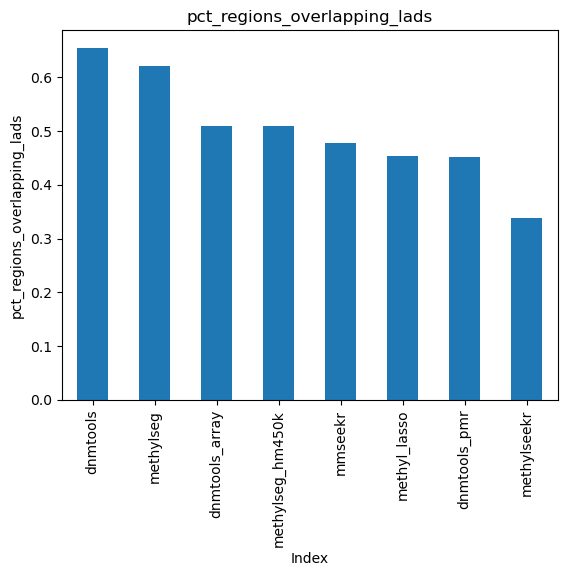

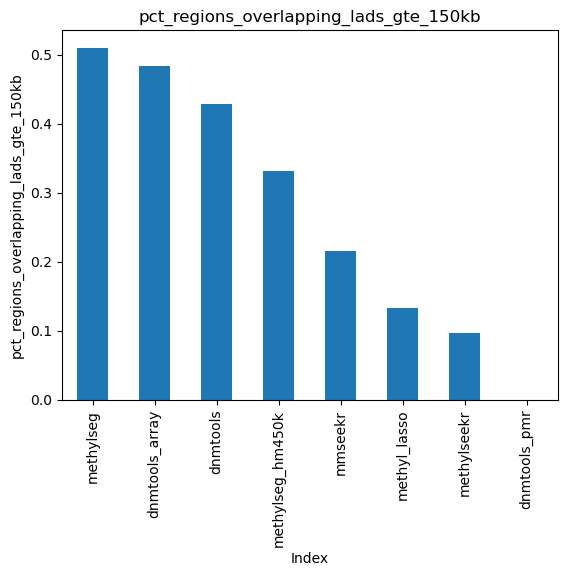

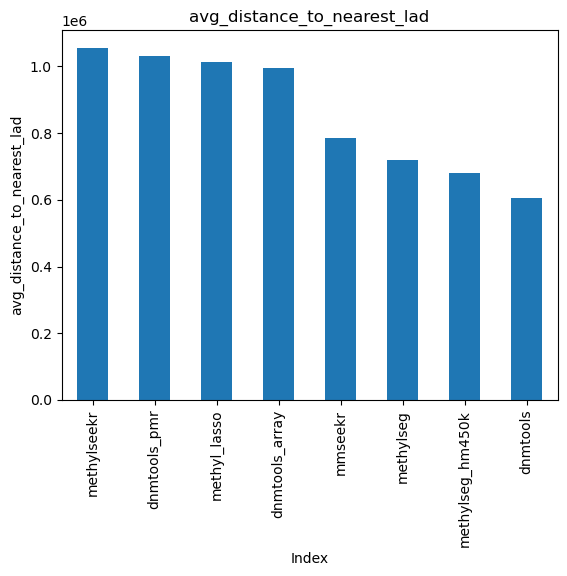

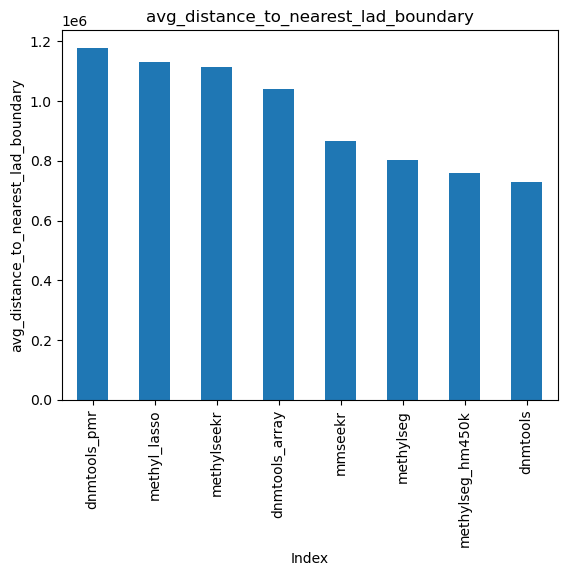

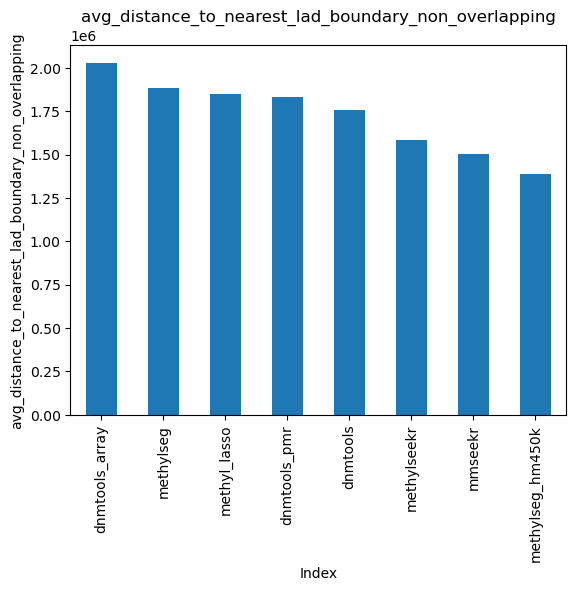

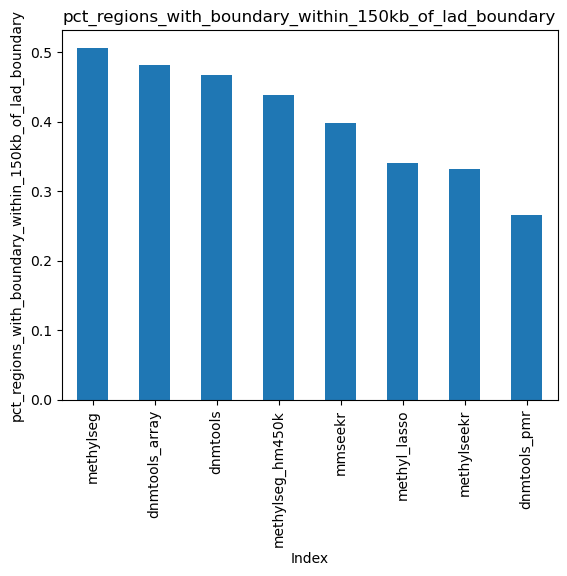

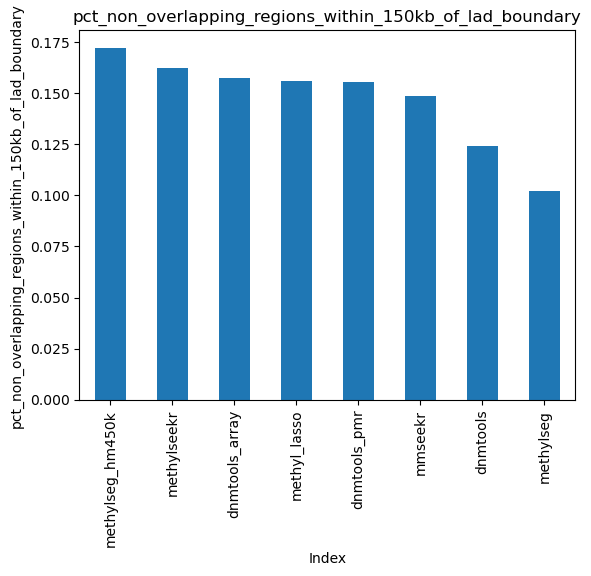

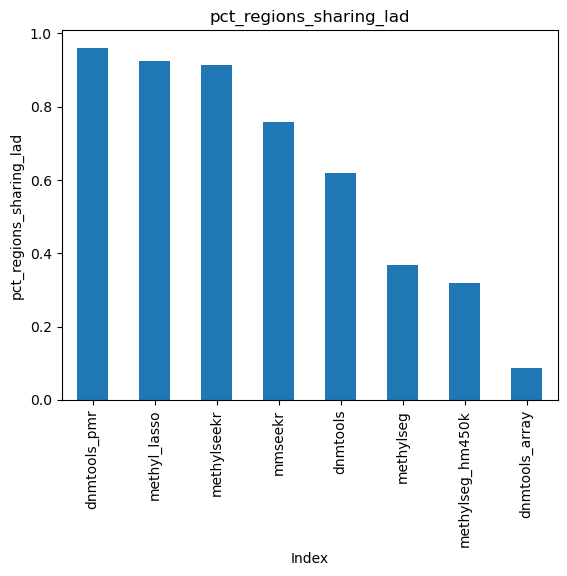

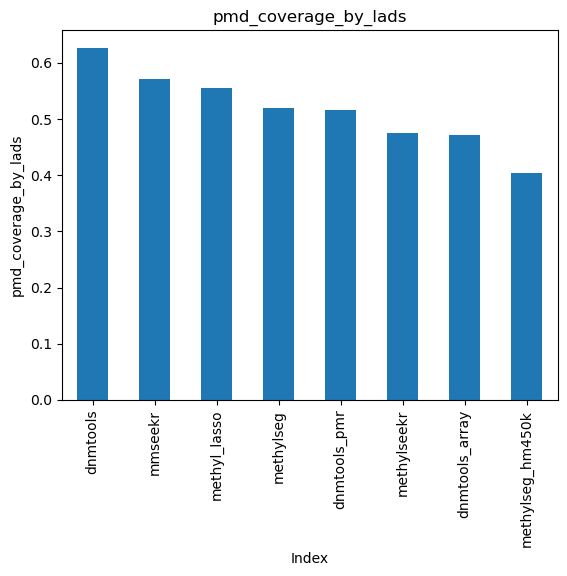

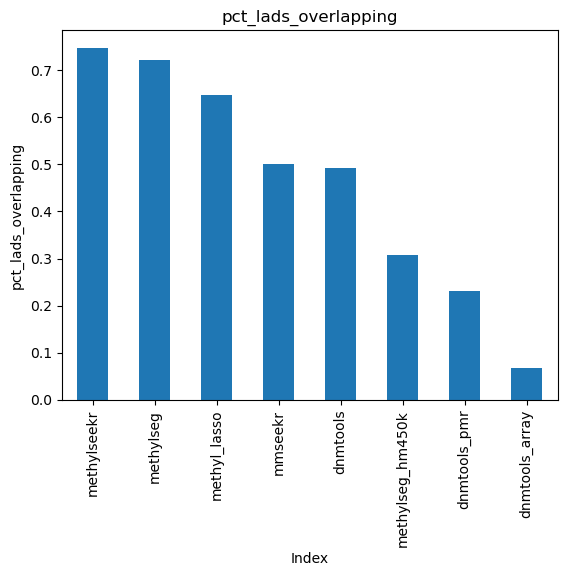

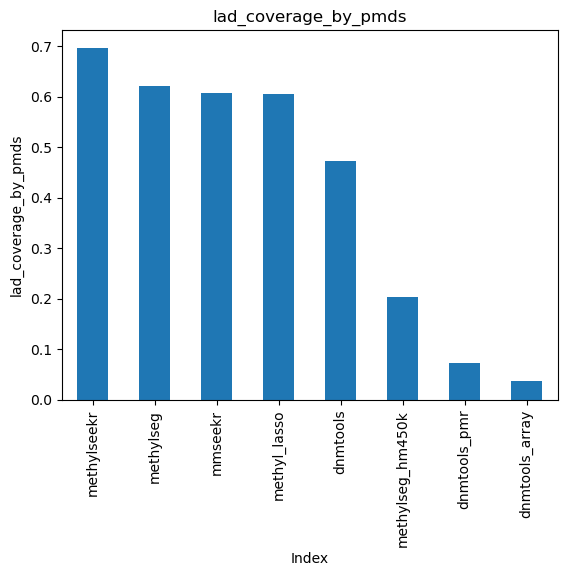

In [25]:
import matplotlib.pyplot as plt

for col in avg_tool_metrics_df.columns:
    plt.figure()

    sorted_series = avg_tool_metrics_df[col].sort_values(ascending=False)
    sorted_series.plot.bar(title=col)

    plt.xlabel("Index")
    plt.ylabel(col)
    plt.show()

In [26]:
from IPython.display import display

DNMTOOLS_METHYLSEG_COMPARISONS = [
    {"comparison_tool": "dnmtools", "reference_methylseg_tool": "methylseg"},
    {"comparison_tool": "dnmtools_array", "reference_methylseg_tool": "methylseg_hm450k"},
]


def load_tool_regions(sample, tool_name):
    tool_row = tools_info_df.loc[tools_info_df["tool"] == tool_name].iloc[0]
    regions_bed_path = segmentation_results_path / "/".join(tool_row["path_parts"]).replace("{sample}", sample)
    if not regions_bed_path.exists():
        print(f"Warning: Path does not exist for {tool_name} {sample}: {regions_bed_path}")
        return pd.DataFrame(columns=["chrom", "start", "end", "region_id", "region_length_bp"])

    regions_df = pd.read_csv(
        regions_bed_path,
        sep="\t",
        header=0 if tool_row["header"] else None,
        index_col=False,
        names=tool_row["columns"],
    ).copy()

    regions_df = regions_df[["chrom", "start", "end"]].copy()
    regions_df["start"] = pd.to_numeric(regions_df["start"], errors="coerce")
    regions_df["end"] = pd.to_numeric(regions_df["end"], errors="coerce")
    regions_df = regions_df.dropna(subset=["chrom", "start", "end"]).copy()
    regions_df["start"] = regions_df["start"].astype(int)
    regions_df["end"] = regions_df["end"].astype(int)
    regions_df = regions_df[regions_df["end"] > regions_df["start"]].reset_index(drop=True)
    regions_df["region_id"] = np.arange(len(regions_df))
    regions_df["region_length_bp"] = regions_df["end"] - regions_df["start"]
    return regions_df


def compute_region_mean_beta(regions_df, meth_df):
    if regions_df.empty or meth_df.empty:
        return pd.DataFrame(columns=["region_id", "mean_beta"])

    overlap_columns = [
        "meth_chrom",
        "meth_start",
        "meth_end",
        "beta",
        "region_chrom",
        "region_start",
        "region_end",
        "region_id",
    ]

    meth_overlap = BedTool.from_dataframe(meth_df[["chrom", "start", "end", "beta"]]).intersect(
        BedTool.from_dataframe(regions_df[["chrom", "start", "end", "region_id"]]),
        wa=True,
        wb=True,
    ).to_dataframe(names=overlap_columns)

    if meth_overlap.empty:
        return pd.DataFrame(columns=["region_id", "mean_beta"])

    meth_overlap["beta"] = pd.to_numeric(meth_overlap["beta"], errors="coerce")
    meth_overlap["region_id"] = pd.to_numeric(meth_overlap["region_id"], errors="coerce")
    meth_overlap = meth_overlap.dropna(subset=["beta", "region_id"]).copy()
    meth_overlap["region_id"] = meth_overlap["region_id"].astype(int)

    return (
        meth_overlap.groupby("region_id", as_index=False)["beta"]
        .mean()
        .rename(columns={"beta": "mean_beta"})
    )


def classify_regions_vs_methylseg(candidate_regions_df, methylseg_regions_df):
    if candidate_regions_df.empty:
        return pd.DataFrame(columns=["region_id", "overlaps_methylseg"])

    candidate_flags = candidate_regions_df[["region_id"]].copy()
    candidate_flags["overlaps_methylseg"] = False

    if methylseg_regions_df.empty:
        return candidate_flags

    overlapping_regions = BedTool.from_dataframe(
        candidate_regions_df[["chrom", "start", "end", "region_id"]]
    ).intersect(
        BedTool.from_dataframe(methylseg_regions_df[["chrom", "start", "end"]]),
        u=True,
    ).to_dataframe(names=["chrom", "start", "end", "region_id"])

    if overlapping_regions.empty:
        return candidate_flags

    overlapping_region_ids = set(pd.to_numeric(overlapping_regions["region_id"], errors="coerce").dropna().astype(int))
    candidate_flags["overlaps_methylseg"] = candidate_flags["region_id"].isin(overlapping_region_ids)
    return candidate_flags


region_detail_rows = []
summary_rows = []
check_rows = []

for comparison in DNMTOOLS_METHYLSEG_COMPARISONS:
    comparison_tool = comparison["comparison_tool"]
    reference_methylseg_tool = comparison["reference_methylseg_tool"]

    for sample in DEFAULT_SELECTED_SAMPLES:
        genome = sample_genomes[sample]
        lad_df_sample = filtered_lad_lookup[genome]

        comparison_regions_df = load_tool_regions(sample, comparison_tool)
        methylseg_regions_df = load_tool_regions(sample, reference_methylseg_tool)
        meth_df = load_sample_methylation(sample, segmentation_results_path, sample_meth_file_parts)

        comparison_lad_overlaps = filter_regions_by_lad_overlap(comparison_regions_df.copy(), lad_df_sample.copy())
        methylseg_lad_overlaps = filter_regions_by_lad_overlap(methylseg_regions_df.copy(), lad_df_sample.copy())

        comparison_lad_ids = set(pd.to_numeric(comparison_lad_overlaps.get("lad_id", pd.Series(dtype=float)), errors="coerce").dropna().astype(int))
        methylseg_lad_ids = set(pd.to_numeric(methylseg_lad_overlaps.get("lad_id", pd.Series(dtype=float)), errors="coerce").dropna().astype(int))
        comparison_only_lad_ids = comparison_lad_ids - methylseg_lad_ids

        comparison_only_overlap_rows = comparison_lad_overlaps[
            pd.to_numeric(comparison_lad_overlaps.get("lad_id", pd.Series(dtype=float)), errors="coerce").isin(comparison_only_lad_ids)
        ].copy()

        comparison_only_region_ids = set(
            pd.to_numeric(comparison_only_overlap_rows.get("region_id", pd.Series(dtype=float)), errors="coerce")
            .dropna()
            .astype(int)
        )

        candidate_regions_df = comparison_regions_df[
            comparison_regions_df["region_id"].isin(comparison_only_region_ids)
        ].copy()

        candidate_regions_df = candidate_regions_df.drop_duplicates("region_id").copy()

        region_beta_df = compute_region_mean_beta(candidate_regions_df, meth_df)
        methylseg_overlap_flags = classify_regions_vs_methylseg(candidate_regions_df, methylseg_regions_df)

        candidate_regions_df = candidate_regions_df.merge(region_beta_df, on="region_id", how="left")
        candidate_regions_df = candidate_regions_df.merge(methylseg_overlap_flags, on="region_id", how="left")
        candidate_regions_df["overlaps_methylseg"] = candidate_regions_df["overlaps_methylseg"].fillna(False).astype(bool)
        candidate_regions_df["comparison_tool"] = comparison_tool
        candidate_regions_df["reference_methylseg_tool"] = reference_methylseg_tool
        candidate_regions_df["sample"] = sample
        candidate_regions_df["genome"] = genome

        region_detail_rows.append(
            candidate_regions_df[
                [
                    "comparison_tool",
                    "reference_methylseg_tool",
                    "sample",
                    "genome",
                    "region_id",
                    "chrom",
                    "start",
                    "end",
                    "region_length_bp",
                    "mean_beta",
                    "overlaps_methylseg",
                ]
            ]
        )

        n_regions = len(candidate_regions_df)
        summary_rows.append(
            {
                "comparison_tool": comparison_tool,
                "reference_methylseg_tool": reference_methylseg_tool,
                "sample": sample,
                "genome": genome,
                "n_regions": n_regions,
                "mean_region_length_bp": candidate_regions_df["region_length_bp"].mean() if n_regions else np.nan,
                "median_region_length_bp": candidate_regions_df["region_length_bp"].median() if n_regions else np.nan,
                "mean_region_beta": candidate_regions_df["mean_beta"].mean() if n_regions else np.nan,
                "median_region_beta": candidate_regions_df["mean_beta"].median() if n_regions else np.nan,
                "pct_regions_overlapping_methylseg": candidate_regions_df["overlaps_methylseg"].mean() if n_regions else np.nan,
                "pct_regions_not_overlapping_methylseg": (~candidate_regions_df["overlaps_methylseg"]).mean() if n_regions else np.nan,
            }
        )

        check_rows.append(
            {
                "comparison_tool": comparison_tool,
                "sample": sample,
                "only_expected_tools": comparison_tool in {"dnmtools", "dnmtools_array"},
                "exact_lad_set_difference": comparison_only_lad_ids == (comparison_lad_ids - methylseg_lad_ids),
                "unique_region_ids": candidate_regions_df["region_id"].is_unique,
                "positive_region_lengths": (candidate_regions_df["region_length_bp"] > 0).all() if n_regions else True,
                "mean_beta_numeric": pd.api.types.is_numeric_dtype(candidate_regions_df["mean_beta"]) if "mean_beta" in candidate_regions_df else True,
                "mean_beta_in_unit_interval": candidate_regions_df["mean_beta"].dropna().between(0, 1).all() if n_regions else True,
                "pcts_sum_to_one": np.isclose(
                    summary_rows[-1]["pct_regions_overlapping_methylseg"] + summary_rows[-1]["pct_regions_not_overlapping_methylseg"],
                    1.0,
                ) if n_regions else True,
            }
        )

dnmtools_only_lad_region_details_df = pd.concat(region_detail_rows, ignore_index=True)
dnmtools_only_lad_summary_df = pd.DataFrame(summary_rows)
avg_dnmtools_only_lad_summary_df = (
    dnmtools_only_lad_summary_df.groupby(["comparison_tool", "reference_methylseg_tool"], as_index=False)
    .mean(numeric_only=True)
)
dnmtools_only_lad_checks_df = pd.DataFrame(check_rows)

dnmtools_only_lad_overlap_table_df = (
    dnmtools_only_lad_region_details_df.groupby("comparison_tool")["overlaps_methylseg"]
    .agg(
        n_regions="size",
        pct_regions_overlapping_methylseg="mean",
    )
    .reset_index()
)
dnmtools_only_lad_overlap_table_df["pct_regions_not_overlapping_methylseg"] = 1 - dnmtools_only_lad_overlap_table_df["pct_regions_overlapping_methylseg"]

display(dnmtools_only_lad_summary_df)
display(avg_dnmtools_only_lad_summary_df)
display(dnmtools_only_lad_overlap_table_df)
display(dnmtools_only_lad_checks_df)

,comparison_tool,reference_methylseg_tool,sample,genome,n_regions,mean_region_length_bp,median_region_length_bp,mean_region_beta,median_region_beta,pct_regions_overlapping_methylseg,pct_regions_not_overlapping_methylseg
0,dnmtools,methylseg,ESO26.wgbs,hg38,63,1.157246e+06,833661.0,0.169385,0.141311,0.714286,0.285714
1,dnmtools,methylseg,TE5.wgbs,hg38,60,1.454172e+06,1019059.5,0.323221,0.325913,0.900000,0.100000
2,dnmtools,methylseg,WGBS_colon-primary-tumor_1_meth,hg38,5,1.244148e+06,759062.0,0.610794,0.590993,1.000000,0.000000
3,dnmtools_array,methylseg_hm450k,ESO26.wgbs,hg38,33,1.386509e+06,1269438.0,0.240764,0.216057,0.484848,0.515152
4,dnmtools_array,methylseg_hm450k,TE5.wgbs,hg38,58,8.164791e+05,680950.5,0.323960,0.317185,0.620690,0.379310
5,dnmtools_array,methylseg_hm450k,WGBS_colon-primary-tumor_1_meth,hg38,1,5.870000e+05,587000.0,0.527172,0.527172,0.000000,1.000000


,comparison_tool,reference_methylseg_tool,n_regions,mean_region_length_bp,median_region_length_bp,mean_region_beta,median_region_beta,pct_regions_overlapping_methylseg,pct_regions_not_overlapping_methylseg
0,dnmtools,methylseg,42.666667,1.285189e+06,870594.166667,0.367800,0.352739,0.871429,0.128571
1,dnmtools_array,methylseg_hm450k,30.666667,9.299960e+05,845796.166667,0.363965,0.353472,0.368513,0.631487


,comparison_tool,n_regions,pct_regions_overlapping_methylseg,pct_regions_not_overlapping_methylseg
0,dnmtools,128,0.812500,0.187500
1,dnmtools_array,92,0.565217,0.434783


,comparison_tool,sample,only_expected_tools,exact_lad_set_difference,unique_region_ids,positive_region_lengths,mean_beta_numeric,mean_beta_in_unit_interval,pcts_sum_to_one
0,dnmtools,ESO26.wgbs,True,True,True,True,True,True,True
1,dnmtools,TE5.wgbs,True,True,True,True,True,True,True
2,dnmtools,WGBS_colon-primary-tumor_1_meth,True,True,True,True,True,True,True
3,dnmtools_array,ESO26.wgbs,True,True,True,True,True,True,True
4,dnmtools_array,TE5.wgbs,True,True,True,True,True,True,True
5,dnmtools_array,WGBS_colon-primary-tumor_1_meth,True,True,True,True,True,True,True


In [27]:
lad_export_rows = []
lad_export_root = notebook_dir / "lad_analysis"

for comparison in DNMTOOLS_METHYLSEG_COMPARISONS:
    comparison_tool = comparison["comparison_tool"]
    reference_methylseg_tool = comparison["reference_methylseg_tool"]

    for sample in DEFAULT_SELECTED_SAMPLES:
        genome = sample_genomes[sample]
        lad_df_sample = filtered_lad_lookup[genome].copy()
        comparison_regions_df = load_tool_regions(sample, comparison_tool)
        methylseg_regions_df = load_tool_regions(sample, reference_methylseg_tool)

        comparison_lad_overlaps = filter_regions_by_lad_overlap(comparison_regions_df.copy(), lad_df_sample.copy())
        methylseg_lad_overlaps = filter_regions_by_lad_overlap(methylseg_regions_df.copy(), lad_df_sample.copy())

        comparison_lad_ids = set(pd.to_numeric(comparison_lad_overlaps.get("lad_id", pd.Series(dtype=float)), errors="coerce").dropna().astype(int))
        methylseg_lad_ids = set(pd.to_numeric(methylseg_lad_overlaps.get("lad_id", pd.Series(dtype=float)), errors="coerce").dropna().astype(int))
        comparison_only_lad_ids = sorted(comparison_lad_ids - methylseg_lad_ids)

        export_lad_df = lad_df_sample.loc[lad_df_sample["lad_id"].isin(comparison_only_lad_ids), ["chrom", "start", "end", "lad_id"]].copy()
        export_lad_df = export_lad_df.sort_values(["chrom", "start", "end"]).reset_index(drop=True)
        export_lad_df["name"] = [
            f"{comparison_tool}_only_vs_{reference_methylseg_tool}_lad_{lad_id}"
            for lad_id in export_lad_df["lad_id"].astype(int)
        ]

        sample_output_dir = lad_export_root / sample
        sample_output_dir.mkdir(parents=True, exist_ok=True)
        export_path = sample_output_dir / f"{sample}.{comparison_tool}_{reference_methylseg_tool}.unique_lads.bed"
        export_lad_df[["chrom", "start", "end", "name"]].to_csv(export_path, sep="\t", header=False, index=False)

        lad_export_rows.append(
            {
                "comparison_tool": comparison_tool,
                "reference_methylseg_tool": reference_methylseg_tool,
                "sample": sample,
                "genome": genome,
                "n_unique_lads": len(export_lad_df),
                "export_path": str(export_path),
            }
        )

dnmtools_only_lad_exports_df = pd.DataFrame(lad_export_rows)
display(dnmtools_only_lad_exports_df)

,comparison_tool,reference_methylseg_tool,sample,genome,n_unique_lads,export_path
0,dnmtools,methylseg,ESO26.wgbs,hg38,1233,/uufs/chpc.utah.edu/common/home/u0914269/cleme...
1,dnmtools,methylseg,TE5.wgbs,hg38,1032,/uufs/chpc.utah.edu/common/home/u0914269/cleme...
2,dnmtools,methylseg,WGBS_colon-primary-tumor_1_meth,hg38,30,/uufs/chpc.utah.edu/common/home/u0914269/cleme...
3,dnmtools_array,methylseg_hm450k,ESO26.wgbs,hg38,217,/uufs/chpc.utah.edu/common/home/u0914269/cleme...
4,dnmtools_array,methylseg_hm450k,TE5.wgbs,hg38,674,/uufs/chpc.utah.edu/common/home/u0914269/cleme...
5,dnmtools_array,methylseg_hm450k,WGBS_colon-primary-tumor_1_meth,hg38,1,/uufs/chpc.utah.edu/common/home/u0914269/cleme...


## Null-model normalization for LAD association metrics

Some LAD metrics can look artificially strong when a method simply calls more regions. The null model below keeps the number of regions, chromosome assignment, and exact region lengths fixed, then randomizes positions within chromosome bounds to estimate the expected overlap and distance-to-LAD signal under a matched null.


In [28]:
import concurrent.futures
import multiprocessing
import os

N_LAD_NULL_PERMUTATIONS = 50
NULL_MODEL_SEED = 0
N_LAD_NULL_WORKERS = max(1, (os.cpu_count() or 1) - 1)
NULL_METRICS = LAD_OVERLAP_METRICS.copy()
CANONICAL_CHROMS = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
CHROM_SIZES_PATHS = {
    "hg19": REFERENCE_DATA_DIR / "hg19.chrom.sizes",
    "hg38": REFERENCE_DATA_DIR / "hg38.chrom.sizes",
}
NULL_METRIC_SHORT_NAME_MAP = {
    "pct_regions_overlapping_lads": "region_pct",
    "pct_regions_overlapping_lads_gte_150kb": "region_pct_150kb",
    "avg_distance_to_nearest_lad": "dist_lad",
    "avg_distance_to_nearest_lad_boundary": "dist_boundary",
    "avg_distance_to_nearest_lad_boundary_non_overlapping": "dist_boundary_nonoverlap",
    "pct_regions_with_boundary_within_150kb_of_lad_boundary": "boundary_pct_150kb",
    "pct_non_overlapping_regions_within_150kb_of_lad_boundary": "boundary_pct_nonoverlap_150kb",
    "pct_regions_sharing_lad": "shared_lad_pct",
    "pmd_coverage_by_lads": "region_cov",
    "pct_lads_overlapping": "lad_pct",
    "lad_coverage_by_pmds": "lad_cov",
}
NULL_METRIC_PLOT_LABEL_MAP = {
    "pct_regions_overlapping_lads": "% regions overlapping LADs",
    "pct_regions_overlapping_lads_gte_150kb": "% regions with >=150 kb LAD overlap",
    "avg_distance_to_nearest_lad": "Avg distance to LAD",
    "avg_distance_to_nearest_lad_boundary": "Avg distance to LAD boundary",
    "avg_distance_to_nearest_lad_boundary_non_overlapping": "Avg boundary distance, non-overlap",
    "pct_regions_with_boundary_within_150kb_of_lad_boundary": "% boundaries within 150 kb",
    "pct_non_overlapping_regions_within_150kb_of_lad_boundary": "% non-overlap boundaries within 150 kb",
    "pct_regions_sharing_lad": "% regions sharing LAD",
    "pmd_coverage_by_lads": "Region coverage by LADs",
    "pct_lads_overlapping": "% LADs overlapping",
    "lad_coverage_by_pmds": "LAD coverage by regions",
}
NULL_STAT_PLOT_SUFFIX_MAP = {
    "enrichment_vs_null": "enrich_vs_null",
    "z_score_vs_null": "z_vs_null",
}
NULL_METRIC_NULL_COLUMN_MAP = {
    metric: f"{NULL_METRIC_SHORT_NAME_MAP[metric]}_null"
    for metric in NULL_METRICS
}
NULL_METRIC_OBSERVED_COLUMN_MAP = {
    metric: f"{NULL_METRIC_SHORT_NAME_MAP[metric]}_observed"
    for metric in NULL_METRICS
}
NULL_METRIC_RELABELED_NULL_COLUMN_MAP = {
    metric: f"{NULL_METRIC_SHORT_NAME_MAP[metric]}_null"
    for metric in NULL_METRICS
}
NULL_METRIC_RELABELED_OBSERVED_COLUMN_MAP = {
    metric: f"{NULL_METRIC_SHORT_NAME_MAP[metric]}_observed_value"
    for metric in NULL_METRICS
}
NULL_METRIC_LABEL_MAP = {
    metric: f"{NULL_METRIC_SHORT_NAME_MAP[metric]}_vs_null"
    for metric in NULL_METRICS
}


def load_chrom_sizes_for_genome(genome):
    chrom_sizes_path = CHROM_SIZES_PATHS[genome]
    chrom_sizes = {}
    with chrom_sizes_path.open() as handle:
        for line in handle:
            chrom, size = line.strip().split("	")[:2]
            if chrom in CANONICAL_CHROMS:
                chrom_sizes[chrom] = int(size)
    return chrom_sizes


def sample_nonoverlapping_intervals_for_chrom(lengths, chrom_size, rng):
    lengths = [int(length) for length in lengths]
    if not lengths:
        return []

    total_length = int(sum(lengths))
    if total_length > int(chrom_size):
        raise ValueError(
            f"Requested {total_length} bp but chromosome only has {chrom_size} bp of valid space"
        )

    shuffled_lengths = rng.permutation(lengths)
    remaining_space = int(chrom_size) - total_length
    gaps = rng.multinomial(remaining_space, np.full(len(shuffled_lengths) + 1, 1 / (len(shuffled_lengths) + 1)))

    intervals = []
    cursor = int(gaps[0])
    for idx, length in enumerate(shuffled_lengths):
        start = cursor
        end = start + int(length)
        intervals.append((start, end, int(length)))
        cursor = end + int(gaps[idx + 1])

    return intervals


def randomize_regions_matched_null(regions_df, chrom_sizes, rng):
    if regions_df.empty:
        return regions_df.copy()

    random_rows = []
    for chrom, chrom_df in regions_df.groupby("chrom", sort=False):
        if chrom not in chrom_sizes:
            raise ValueError(f"Chromosome {chrom} is missing from chromosome sizes")

        intervals = sample_nonoverlapping_intervals_for_chrom(
            chrom_df["region_length"].astype(int).tolist(),
            chrom_sizes[chrom],
            rng,
        )
        for start, end, length in intervals:
            random_rows.append(
                {
                    "chrom": chrom,
                    "start": int(start),
                    "end": int(end),
                    "region_length": int(length),
                }
            )

    randomized_df = pd.DataFrame(random_rows)
    randomized_df = randomized_df.sort_values(["chrom", "start", "end"]).reset_index(drop=True)
    randomized_df["region_id"] = np.arange(len(randomized_df))
    return randomized_df


def compute_lad_null_metrics(overlaps_df, regions_df, lad_df):
    metrics_df = get_overlap_scores(overlaps_df, regions_df, lad_df)
    return {metric: metrics_df.iloc[0][metric] for metric in NULL_METRICS}


def regions_have_no_overlap(interval_df):
    if interval_df.empty:
        return True
    for _, chrom_df in interval_df.sort_values(["chrom", "start", "end"]).groupby("chrom"):
        starts = chrom_df["start"].to_numpy(dtype=np.int64)
        ends = chrom_df["end"].to_numpy(dtype=np.int64)
        if len(starts) > 1 and np.any(starts[1:] < ends[:-1]):
            return False
    return True


def _run_single_lad_null_permutation(args):
    perm_idx = args["perm_idx"]
    seed = args["seed"]
    observed_regions_df = args["observed_regions_df"]
    lad_df_sample = args["lad_df_sample"]
    chrom_sizes = args["chrom_sizes"]

    rng = np.random.default_rng(seed)
    permuted_regions_df = randomize_regions_matched_null(observed_regions_df.copy(), chrom_sizes, rng)
    permuted_overlaps_df = filter_regions_by_lad_overlap(permuted_regions_df.copy(), lad_df_sample.copy())
    permuted_metrics = compute_lad_null_metrics(permuted_overlaps_df, permuted_regions_df.copy(), lad_df_sample.copy())

    observed_chrom_counts = observed_regions_df["chrom"].value_counts().sort_index()
    permuted_chrom_counts = permuted_regions_df["chrom"].value_counts().sort_index()
    check_flags = {
        "same_region_count": len(permuted_regions_df) == len(observed_regions_df),
        "same_chrom_counts": observed_chrom_counts.equals(permuted_chrom_counts),
        "same_length_multiset_by_chrom": True,
        "within_chrom_bounds": (
            (permuted_regions_df["start"] >= 0).all()
            and (permuted_regions_df["end"] > permuted_regions_df["start"]).all()
            and (permuted_regions_df.apply(lambda row: row["end"] <= chrom_sizes[row["chrom"]], axis=1)).all()
        ),
        "strictly_positive_lengths": (permuted_regions_df["region_length"] > 0).all(),
        "non_overlapping_intervals": regions_have_no_overlap(permuted_regions_df),
    }

    for chrom, observed_chrom_df in observed_regions_df.groupby("chrom"):
        observed_lengths = sorted(observed_chrom_df["region_length"].astype(int).tolist())
        permuted_lengths = sorted(
            permuted_regions_df.loc[permuted_regions_df["chrom"] == chrom, "region_length"].astype(int).tolist()
        )
        check_flags["same_length_multiset_by_chrom"] &= observed_lengths == permuted_lengths

    return {
        "perm_idx": perm_idx,
        **{NULL_METRIC_NULL_COLUMN_MAP[metric]: permuted_metrics[metric] for metric in NULL_METRICS},
        **check_flags,
    }


def _run_lad_null_job(args):
    tool = args["tool"]
    sample = args["sample"]
    genome = args["genome"]
    observed_regions_df = args["observed_regions_df"].copy()
    lad_df_sample = args["lad_df_sample"].copy()
    chrom_sizes = args["chrom_sizes"]
    permutation_seeds = args["permutation_seeds"]

    status = "ok"
    error_message = ""
    completed_permutations = 0
    check_flags = {
        "same_region_count": True,
        "same_chrom_counts": True,
        "same_length_multiset_by_chrom": True,
        "within_chrom_bounds": True,
        "strictly_positive_lengths": True,
        "non_overlapping_intervals": True,
    }

    if observed_regions_df.empty:
        status = "empty"
        observed_metrics = {metric: np.nan for metric in NULL_METRICS}
        permutation_rows = []
    else:
        observed_overlaps_df = filter_regions_by_lad_overlap(observed_regions_df.copy(), lad_df_sample.copy())
        observed_metrics = compute_lad_null_metrics(observed_overlaps_df, observed_regions_df.copy(), lad_df_sample.copy())
        permutation_rows = []
        try:
            for perm_idx, seed in enumerate(permutation_seeds):
                perm_result = _run_single_lad_null_permutation(
                    {
                        "perm_idx": perm_idx,
                        "seed": int(seed),
                        "observed_regions_df": observed_regions_df.copy(),
                        "lad_df_sample": lad_df_sample.copy(),
                        "chrom_sizes": chrom_sizes,
                    }
                )
                for flag_name in check_flags:
                    check_flags[flag_name] &= perm_result[flag_name]
                permutation_rows.append(
                    {
                        "tool": tool,
                        "sample": sample,
                        "genome": genome,
                        "perm_idx": perm_result["perm_idx"],
                        **{NULL_METRIC_NULL_COLUMN_MAP[metric]: perm_result[NULL_METRIC_NULL_COLUMN_MAP[metric]] for metric in NULL_METRICS},
                    }
                )
                completed_permutations += 1
        except Exception as exc:
            status = "failed"
            error_message = str(exc)

    observed_row = {
        "tool": tool,
        "sample": sample,
        "genome": genome,
        **{NULL_METRIC_OBSERVED_COLUMN_MAP[metric]: observed_metrics[metric] for metric in NULL_METRICS},
        "n_permutations_completed": completed_permutations,
        "status": status,
        "error_message": error_message,
    }
    check_row = {
        "tool": tool,
        "sample": sample,
        "genome": genome,
        "n_permutations_completed": completed_permutations,
        **check_flags,
    }
    return {
        "observed_row": observed_row,
        "permutation_rows": permutation_rows,
        "check_row": check_row,
    }


In [29]:
N_LAD_NULL_WORKERS

111

In [30]:
lad_null_observed_rows = []
lad_null_permutation_rows = []
lad_null_check_rows = []
master_rng = np.random.default_rng(NULL_MODEL_SEED)
process_pool_context = multiprocessing.get_context("fork")

job_args = []
for tool in tools_info_df["tool"].unique():
    print(f"Queueing LAD null model for tool: {tool}")
    for sample in DEFAULT_SELECTED_SAMPLES:
        genome = sample_genomes[sample]
        lad_df_sample = filtered_lad_lookup[genome].copy()
        chrom_sizes = load_chrom_sizes_for_genome(genome)
        observed_regions_df = load_tool_regions(sample, tool).copy()
        observed_regions_df["region_length"] = observed_regions_df.get(
            "region_length",
            observed_regions_df.get("region_length_bp", observed_regions_df.get("end", pd.Series(dtype=int)) - observed_regions_df.get("start", pd.Series(dtype=int))),
        )
        sample_rng = np.random.default_rng(master_rng.integers(0, 2**32 - 1))
        permutation_seeds = [int(sample_rng.integers(0, 2**32 - 1)) for _ in range(N_LAD_NULL_PERMUTATIONS)]
        job_args.append(
            {
                "tool": tool,
                "sample": sample,
                "genome": genome,
                "lad_df_sample": lad_df_sample,
                "chrom_sizes": chrom_sizes,
                "observed_regions_df": observed_regions_df,
                "permutation_seeds": permutation_seeds,
            }
        )

if N_LAD_NULL_WORKERS <= 1:
    job_results = [_run_lad_null_job(arg) for arg in job_args]
else:
    with concurrent.futures.ProcessPoolExecutor(
        max_workers=N_LAD_NULL_WORKERS,
        mp_context=process_pool_context,
    ) as executor:
        job_results = list(executor.map(_run_lad_null_job, job_args))

for job_result in job_results:
    lad_null_observed_rows.append(job_result["observed_row"])
    lad_null_permutation_rows.extend(job_result["permutation_rows"])
    lad_null_check_rows.append(job_result["check_row"])


Queueing LAD null model for tool: methylseg
Queueing LAD null model for tool: methylseg_hm450k
Queueing LAD null model for tool: methylseekr
Queueing LAD null model for tool: dnmtools
Queueing LAD null model for tool: dnmtools_array
Queueing LAD null model for tool: dnmtools_pmr
Queueing LAD null model for tool: mmseekr
Queueing LAD null model for tool: methyl_lasso


In [31]:
lad_null_permutation_df = pd.DataFrame(
    lad_null_permutation_rows,
    columns=[
        "tool",
        "sample",
        "genome",
        "perm_idx",
        *[NULL_METRIC_NULL_COLUMN_MAP[metric] for metric in NULL_METRICS],
    ],
)
lad_null_permutation_df = lad_null_permutation_df.rename(
    columns={
        "perm_idx": "null_perm_idx",
        **{
            NULL_METRIC_NULL_COLUMN_MAP[metric]: NULL_METRIC_RELABELED_NULL_COLUMN_MAP[metric]
            for metric in NULL_METRICS
        },
    }
)
lad_null_observed_df = pd.DataFrame(lad_null_observed_rows).rename(
    columns={
        **{
            NULL_METRIC_OBSERVED_COLUMN_MAP[metric]: NULL_METRIC_RELABELED_OBSERVED_COLUMN_MAP[metric]
            for metric in NULL_METRICS
        },
        "n_permutations_completed": "n_null_permutations_completed",
        "status": "null_status",
        "error_message": "null_error_message",
    }
)
lad_null_checks_df = pd.DataFrame(lad_null_check_rows).rename(
    columns={"n_permutations_completed": "n_null_permutations_completed"}
)

summary_rows = []
for observed_row in lad_null_observed_df.itertuples(index=False):
    perm_subset = lad_null_permutation_df.loc[
        (lad_null_permutation_df["tool"] == observed_row.tool)
        & (lad_null_permutation_df["sample"] == observed_row.sample)
    ].copy()

    for metric in NULL_METRICS:
        observed_value = getattr(
            observed_row,
            NULL_METRIC_RELABELED_OBSERVED_COLUMN_MAP[metric],
        )
        perm_col = NULL_METRIC_RELABELED_NULL_COLUMN_MAP[metric]
        perm_values = perm_subset[perm_col] if (not perm_subset.empty and perm_col in perm_subset.columns) else pd.Series(dtype=float)

        perm_values = pd.to_numeric(perm_values, errors="coerce").dropna()
        if len(perm_values) == 0:
            null_mean = np.nan
            null_sd = np.nan
        elif len(perm_values) == 1:
            null_mean = perm_values.mean()
            null_sd = 0.0
        else:
            null_mean = perm_values.mean()
            null_sd = perm_values.std(ddof=1)

        if pd.isna(null_mean):
            enrichment = np.nan
        elif null_mean == 0:
            if pd.isna(observed_value) or observed_value == 0:
                enrichment = np.nan
            else:
                enrichment = np.inf
        else:
            enrichment = observed_value / null_mean

        if pd.isna(null_sd):
            z_score = np.nan
        elif null_sd == 0:
            if observed_value == null_mean:
                z_score = 0.0
            else:
                z_score = np.nan
        else:
            z_score = (observed_value - null_mean) / null_sd

        summary_rows.append(
            {
                "tool": observed_row.tool,
                "sample": observed_row.sample,
                "genome": observed_row.genome,
                "metric_vs_null": NULL_METRIC_LABEL_MAP[metric],
                "observed_value": observed_value,
                "null_mean": null_mean,
                "null_sd": null_sd,
                "enrichment_vs_null": enrichment,
                "z_score_vs_null": z_score,
                "n_null_permutations_completed": observed_row.n_null_permutations_completed,
                "null_status": observed_row.null_status,
                "null_error_message": observed_row.null_error_message,
            }
        )

lad_null_summary_df = pd.DataFrame(summary_rows)
lad_null_summary_avg_df = (
    lad_null_summary_df.groupby(["tool", "metric_vs_null"], as_index=False)
    .agg(
        observed_value=("observed_value", "mean"),
        null_mean=("null_mean", "mean"),
        null_sd=("null_sd", "mean"),
        enrichment_vs_null=("enrichment_vs_null", "mean"),
        z_score_vs_null=("z_score_vs_null", "mean"),
        n_null_permutations_completed=("n_null_permutations_completed", "mean"),
        n_samples=("sample", "nunique"),
    )
)

lad_null_plot_df = lad_null_summary_avg_df.pivot(
    index="tool",
    columns="metric_vs_null",
    values=["enrichment_vs_null", "z_score_vs_null"],
)
lad_null_plot_df.columns = [
    f"{metric}_{NULL_STAT_PLOT_SUFFIX_MAP[stat]}"
    for stat, metric in lad_null_plot_df.columns
]
lad_null_plot_df = lad_null_plot_df.replace([np.inf, -np.inf], np.nan)


display(lad_null_summary_df)
display(lad_null_summary_avg_df)
display(lad_null_plot_df)
display(lad_null_checks_df)


,tool,sample,genome,metric_vs_null,observed_value,null_mean,null_sd,enrichment_vs_null,z_score_vs_null,n_null_permutations_completed,null_status,null_error_message
0,methylseg,ESO26.wgbs,hg38,region_pct_vs_null,6.581709e-01,5.604798e-01,0.008352,1.174299,11.696461,50,ok,
1,methylseg,ESO26.wgbs,hg38,region_pct_150kb_vs_null,5.397301e-01,4.460120e-01,0.008316,1.210125,11.268954,50,ok,
2,methylseg,ESO26.wgbs,hg38,dist_lad_vs_null,6.544879e+05,1.047381e+06,18373.564793,0.624881,-21.383583,50,ok,
3,methylseg,ESO26.wgbs,hg38,dist_boundary_vs_null,7.529443e+05,1.157499e+06,18569.234772,0.650493,-21.786266,50,ok,
4,methylseg,ESO26.wgbs,hg38,dist_boundary_nonoverlap_vs_null,1.914664e+06,2.383688e+06,55308.174669,0.803236,-8.480200,50,ok,
...,...,...,...,...,...,...,...,...,...,...,...,...
259,methyl_lasso,WGBS_colon-primary-tumor_1_meth,hg38,boundary_pct_nonoverlap_150kb_vs_null,1.543817e-01,1.466975e-01,0.003164,1.052382,2.428379,50,ok,
260,methyl_lasso,WGBS_colon-primary-tumor_1_meth,hg38,shared_lad_pct_vs_null,9.114136e-01,8.766533e-01,0.003093,1.039651,11.236915,50,ok,
261,methyl_lasso,WGBS_colon-primary-tumor_1_meth,hg38,region_cov_vs_null,5.410104e-01,3.797508e-01,0.003419,1.424646,47.168794,50,ok,
262,methyl_lasso,WGBS_colon-primary-tumor_1_meth,hg38,lad_pct_vs_null,7.526090e-01,5.732781e-01,0.039436,1.312817,4.547437,50,ok,


,tool,metric_vs_null,observed_value,null_mean,null_sd,enrichment_vs_null,z_score_vs_null,n_null_permutations_completed,n_samples
0,dnmtools,boundary_pct_150kb_vs_null,4.670173e-01,3.774194e-01,0.009329,1.223006,9.201031,50.0,3
1,dnmtools,boundary_pct_nonoverlap_150kb_vs_null,1.239681e-01,1.336720e-01,0.011438,0.937662,-1.440938,50.0,3
2,dnmtools,dist_boundary_nonoverlap_vs_null,1.756375e+06,2.194812e+06,51854.594134,0.804217,-8.618490,50.0,3
3,dnmtools,dist_boundary_vs_null,7.290974e+05,1.138065e+06,20003.387758,0.633675,-21.163146,50.0,3
4,dnmtools,dist_lad_vs_null,6.059012e+05,1.024975e+06,19731.115594,0.586232,-22.116213,50.0,3
...,...,...,...,...,...,...,...,...,...
83,mmseekr,lad_pct_vs_null,5.007673e-01,4.194168e-01,0.051668,1.196325,1.579086,50.0,3
84,mmseekr,region_cov_vs_null,5.714968e-01,3.752009e-01,0.005914,1.523412,34.031810,50.0,3
85,mmseekr,region_pct_150kb_vs_null,2.153500e-01,1.626302e-01,0.003559,1.330533,14.734228,50.0,3
86,mmseekr,region_pct_vs_null,4.783203e-01,4.415865e-01,0.005298,1.083185,6.713009,50.0,3


,boundary_pct_150kb_vs_null_enrich_vs_null,boundary_pct_nonoverlap_150kb_vs_null_enrich_vs_null,dist_boundary_nonoverlap_vs_null_enrich_vs_null,dist_boundary_vs_null_enrich_vs_null,dist_lad_vs_null_enrich_vs_null,lad_cov_vs_null_enrich_vs_null,lad_pct_vs_null_enrich_vs_null,region_cov_vs_null_enrich_vs_null,region_pct_150kb_vs_null_enrich_vs_null,region_pct_vs_null_enrich_vs_null,...,boundary_pct_nonoverlap_150kb_vs_null_z_vs_null,dist_boundary_nonoverlap_vs_null_z_vs_null,dist_boundary_vs_null_z_vs_null,dist_lad_vs_null_z_vs_null,lad_cov_vs_null_z_vs_null,lad_pct_vs_null_z_vs_null,region_cov_vs_null_z_vs_null,region_pct_150kb_vs_null_z_vs_null,region_pct_vs_null_z_vs_null,shared_lad_pct_vs_null_z_vs_null
tool,,,,,,,,,,,,,,,,,,,,,
dnmtools,1.223006,0.937662,0.804217,0.633675,0.586232,1.613927,1.204777,1.613927,1.368349,1.262662,...,-1.440938,-8.618490,-21.163146,-22.116213,30.556788,1.763492,30.556788,16.289334,21.036836,27.397872
dnmtools_array,1.197021,1.201637,1.462505,1.525120,1.877423,1.198244,2.239632,1.198244,1.053418,0.920345,...,0.312917,6.350008,127.580833,102.425496,4.311035,23.581457,4.311035,3.205503,1.148848,13.702752
dnmtools_pmr,1.023126,0.935290,0.901296,0.836629,0.793657,1.377703,0.792774,1.377703,0.000000,1.217026,...,-6.471271,-139.343876,-655.548978,-717.995878,85.248164,-15.832678,85.248164,-0.298883,164.194876,18.528411
methyl_lasso,1.118658,1.039514,0.854117,0.808111,0.785988,1.453398,1.150479,1.453398,1.474460,1.113496,...,2.222446,-14.771547,-21.393389,-21.867432,46.029617,2.244350,46.029617,24.956886,17.394912,16.607649
methylseekr,1.123874,1.076207,0.728297,0.781706,0.802822,1.254929,1.138421,1.254929,1.277350,0.849800,...,3.193481,-10.240608,-8.898793,-7.495901,29.920849,2.187530,29.920849,14.537658,-12.810614,-0.921685
methylseg,1.265727,0.819236,0.791661,0.689445,0.680910,1.358003,1.359469,1.358003,1.160923,1.112234,...,-1.690949,-7.296553,-15.400248,-14.555814,24.036911,2.867532,24.036911,9.757452,8.598814,10.602785
methylseg_hm450k,1.144123,1.248147,0.686930,0.678891,0.668697,1.066259,1.115315,1.066259,1.011598,1.030314,...,3.052376,-15.420971,-21.384668,-20.337729,2.558219,0.753627,2.558219,0.598339,2.421738,15.397716
mmseekr,1.211571,1.008526,0.717617,0.677616,0.668852,1.523412,1.196325,1.523412,1.330533,1.083185,...,0.218754,-11.262828,-13.749784,-12.815678,34.031810,1.579086,34.031810,14.734228,6.713009,8.952884


,tool,sample,genome,n_null_permutations_completed,same_region_count,same_chrom_counts,same_length_multiset_by_chrom,within_chrom_bounds,strictly_positive_lengths,non_overlapping_intervals
0,methylseg,ESO26.wgbs,hg38,50,True,True,True,True,True,True
1,methylseg,TE5.wgbs,hg38,50,True,True,True,True,True,True
2,methylseg,WGBS_colon-primary-tumor_1_meth,hg38,50,True,True,True,True,True,True
3,methylseg_hm450k,ESO26.wgbs,hg38,50,True,True,True,True,True,True
4,methylseg_hm450k,TE5.wgbs,hg38,50,True,True,True,True,True,True
5,methylseg_hm450k,WGBS_colon-primary-tumor_1_meth,hg38,50,True,True,True,True,True,True
6,methylseekr,ESO26.wgbs,hg38,50,True,True,True,True,True,True
7,methylseekr,TE5.wgbs,hg38,50,True,True,True,True,True,True
8,methylseekr,WGBS_colon-primary-tumor_1_meth,hg38,50,True,True,True,True,True,True
9,dnmtools,ESO26.wgbs,hg38,50,True,True,True,True,True,True


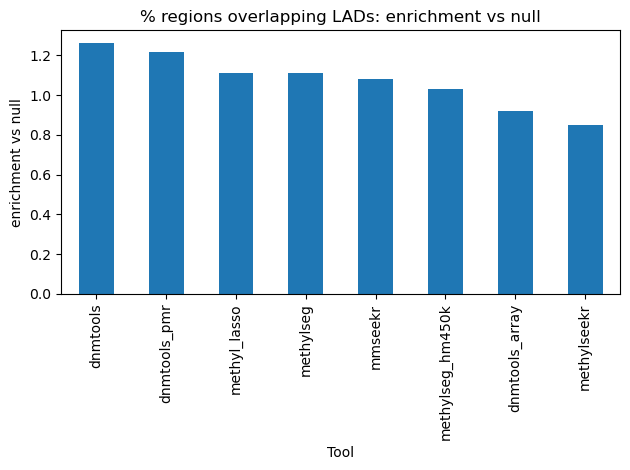

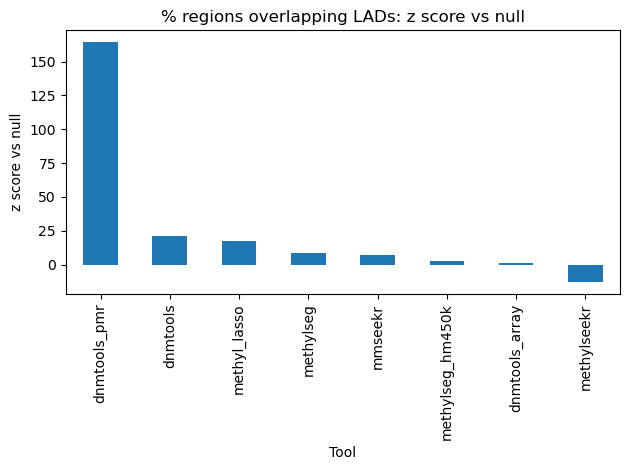

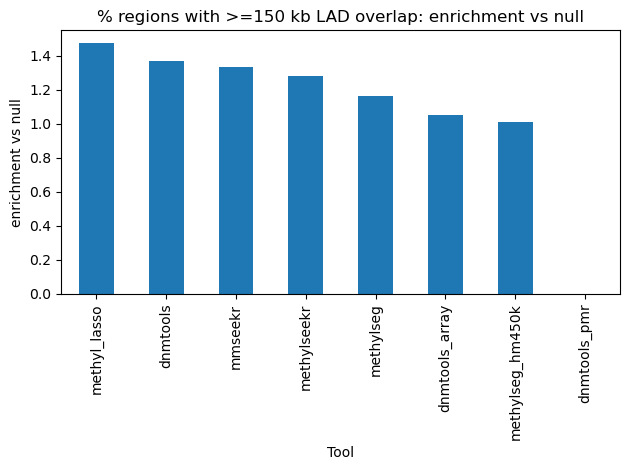

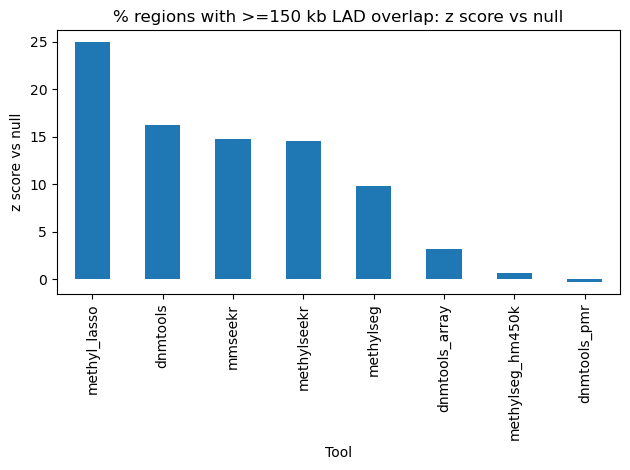

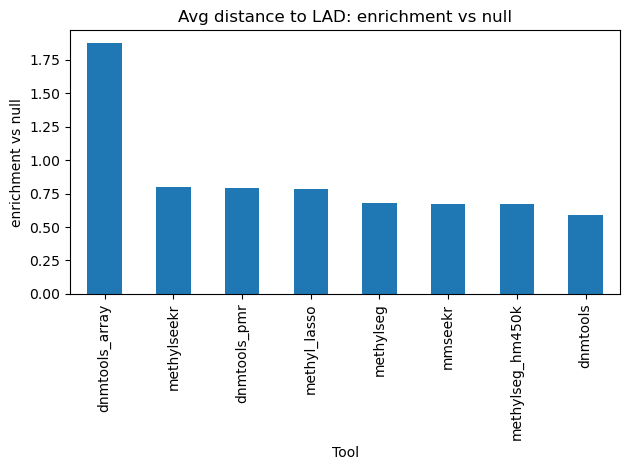

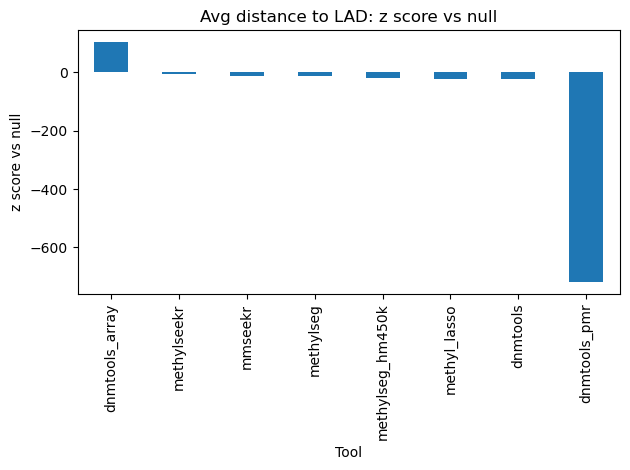

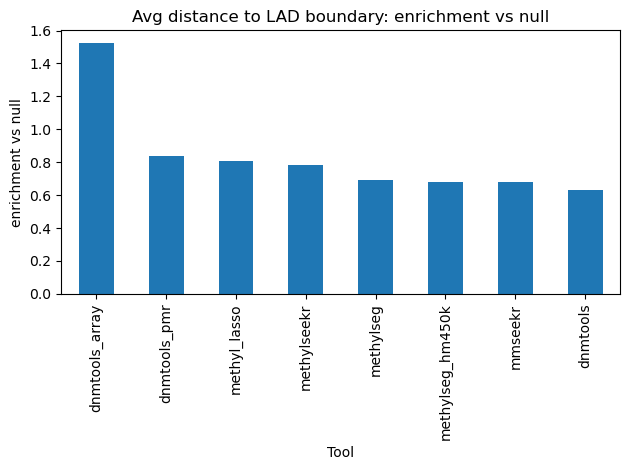

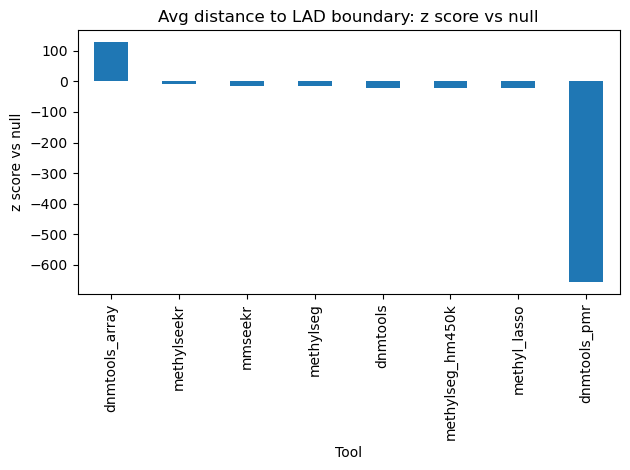

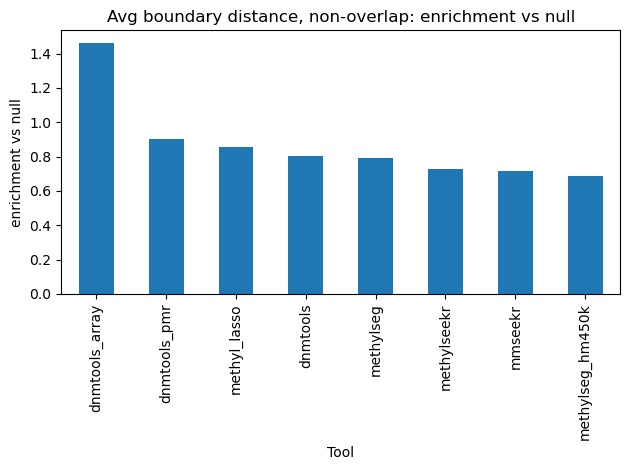

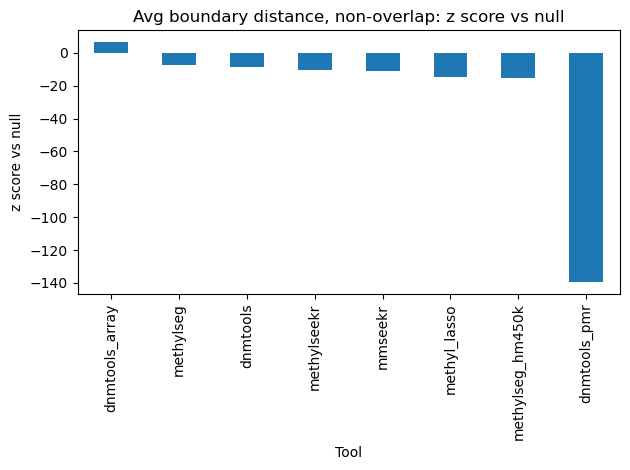

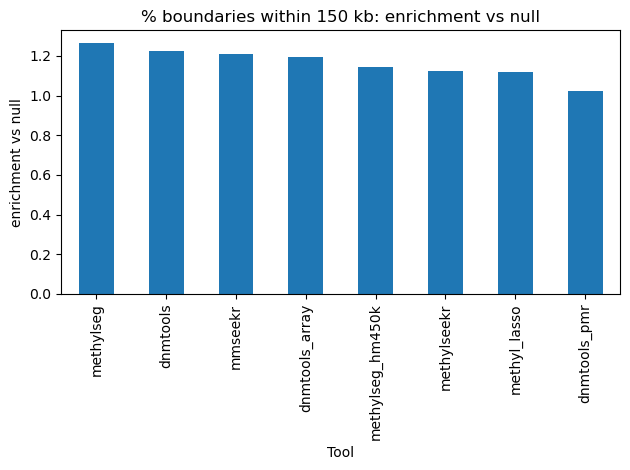

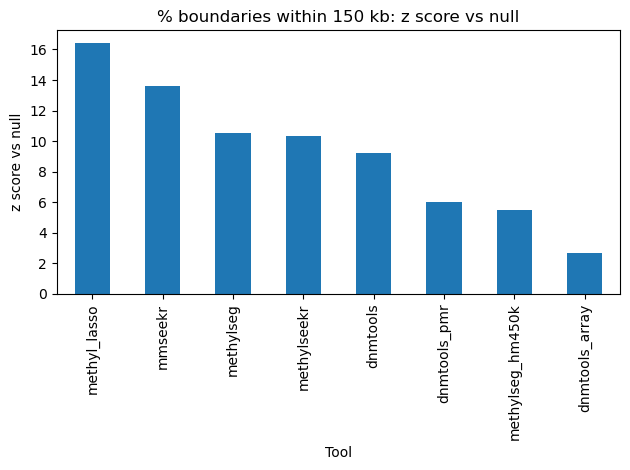

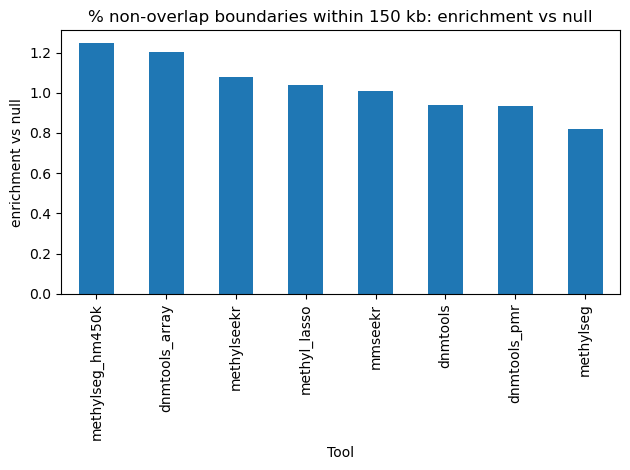

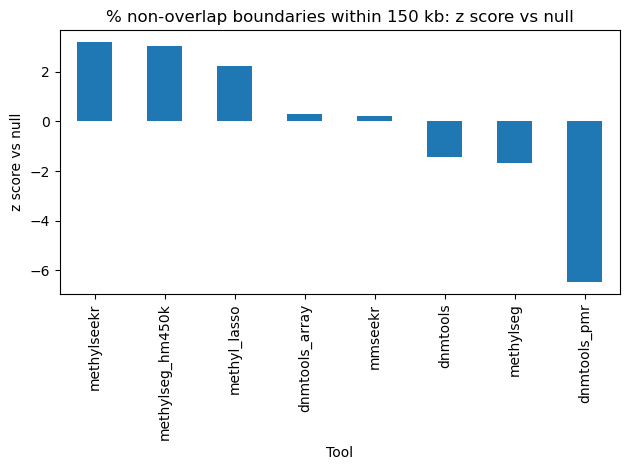

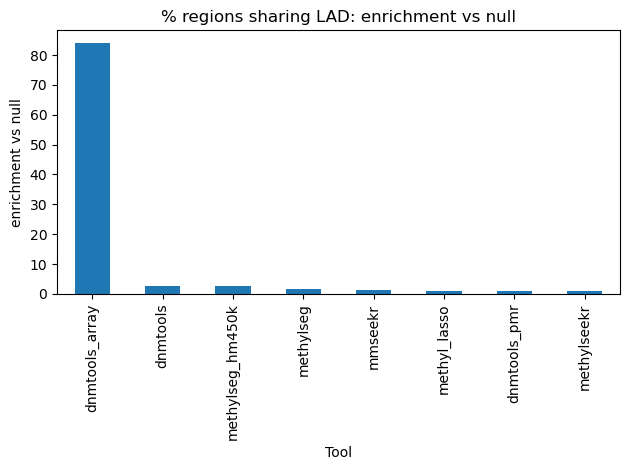

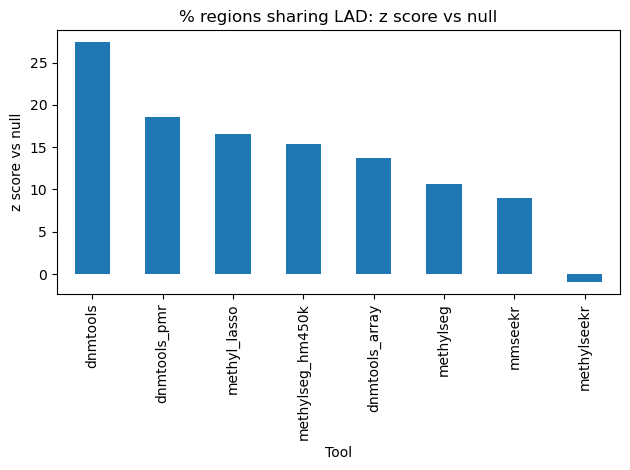

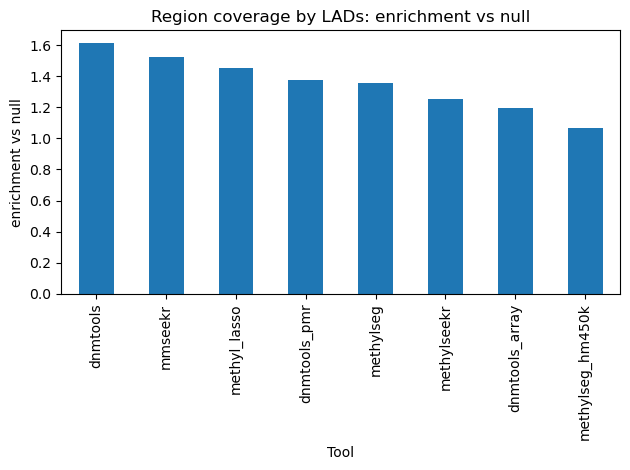

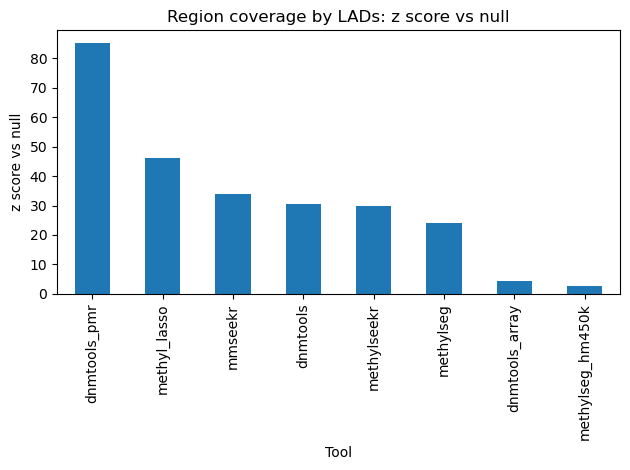

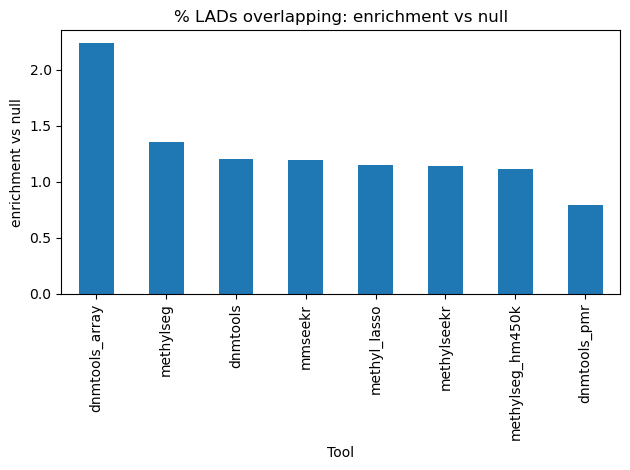

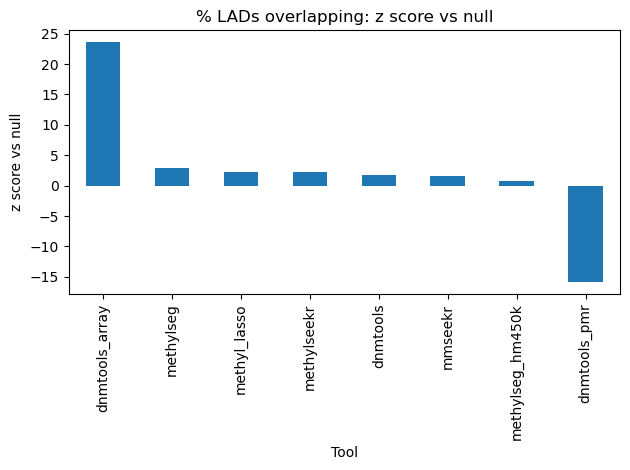

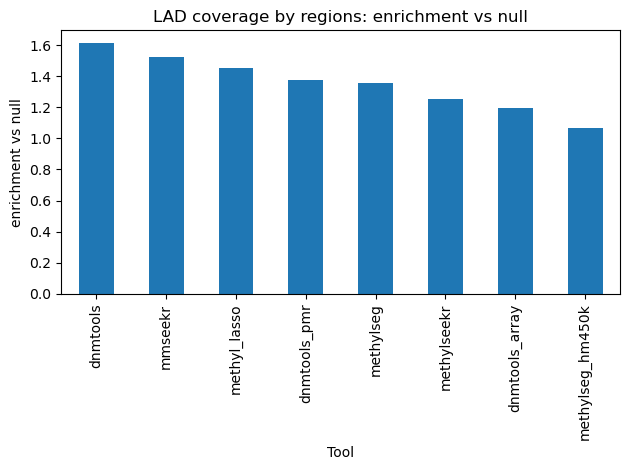

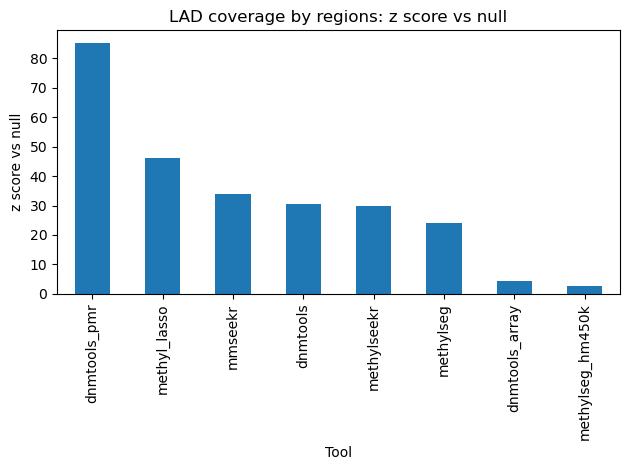

In [32]:
for metric in NULL_METRICS:
    metric_key = NULL_METRIC_LABEL_MAP[metric]
    metric_plot_label = NULL_METRIC_PLOT_LABEL_MAP[metric]

    for summary_col, plot_suffix in NULL_STAT_PLOT_SUFFIX_MAP.items():
        col = f"{metric_key}_{plot_suffix}"
        if col not in lad_null_plot_df.columns:
            continue

        sorted_series = lad_null_plot_df[col].dropna().sort_values(ascending=False)
        if sorted_series.empty:
            continue

        plt.figure()
        sorted_series.plot.bar(title=f"{metric_plot_label}: {summary_col.replace('_', ' ')}")
        plt.xlabel("Tool")
        plt.ylabel(summary_col.replace("_", " "))
        plt.tight_layout()
        plt.show()
